In [ ]:
# Installation des packages nécessaires
!pip install earthengine-api   # API officielle GEE
!pip install geemap             # Visualisation interactive (cartes)
!pip install pandas numpy matplotlib
!pip install tensorflow         # ou pytorch selon ton choix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.2 MB/s eta 0:00:00


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  Mount Google Drive for persistent storage              ║
# ╚══════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

# Define a base path in your Google Drive where files will be saved
# You can change 'fire_risk_data' to any folder name you prefer
DRIVE_BASE_PATH = '/content/drive/MyDrive/fire_risk_data'

# Create the directory if it doesn't exist
import os
os.makedirs(DRIVE_BASE_PATH, exist_ok=True)
print(f"✅ Google Drive mounted and base path set to: {DRIVE_BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted and base path set to: /content/drive/MyDrive/fire_risk_data


In [ ]:
import ee
import geemap

# Étape d'authentification (ouvre un navigateur, tu cliques "autoriser")
# À faire UNE SEULE FOIS sur ta machine
ee.Authenticate()

# Initialiser GEE (à faire au début de chaque session)
ee.Initialize(project='valiant-azimuth-495418-e5')
# → Si tu n'as pas de project-id, utilise : ee.Initialize()

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Imports & Initialisation                   ║
# ╚══════════════════════════════════════════════════════════╝

import ee
import geemap
import pandas as pd
import numpy as np
import time
import glob

ee.Initialize(project='valiant-azimuth-495418-e5')
print("✅ Google Earth Engine initialisé")

✅ Google Earth Engine initialisé


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Paramètres globaux                         ║
# ╚══════════════════════════════════════════════════════════╝

REGION     = ee.Geometry.Rectangle([-124.5, 32.5, -114.0, 42.0])
START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'
SCALE      = 25000   # 25km

print("✅ Paramètres définis :")
print(f"   Région  : Californie [-124.5, 32.5, -114.0, 42.0]")
print(f"   Période : {START_DATE} → {END_DATE}")
print(f"   Scale   : {SCALE//1000}km")

✅ Paramètres définis :
   Région  : Californie [-124.5, 32.5, -114.0, 42.0]
   Période : 2019-01-01 → 2023-12-31
   Scale   : 25km


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Grille de points server-side               ║
# ╚══════════════════════════════════════════════════════════╝

# Grille créée DANS GEE (server-side) pour éviter les
# limitations mémoire d'une FeatureCollection Python

lons_list = ee.List.sequence(-124.5, -114.25, 0.25)
lats_list = ee.List.sequence(32.5,    41.75,  0.25)

def make_points(lon):
    lon = ee.Number(lon)
    def inner(lat):
        lat = ee.Number(lat)
        return ee.Feature(
            ee.Geometry.Point([lon, lat]),
            {'lon': lon, 'lat': lat}
        )
    return lats_list.map(inner)

nested       = lons_list.map(make_points)
flat         = nested.flatten()
grid_fc_server = ee.FeatureCollection(flat)

n = grid_fc_server.size().getInfo()
print(f"✅ Grille server-side : {n} points")
print(f"   (les points dans l'océan seront exclus automatiquement)")

✅ Grille server-side : 1596 points
   (les points dans l'océan seront exclus automatiquement)


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification des collections GEE           ║
# ╚══════════════════════════════════════════════════════════╝

firms = (ee.ImageCollection('FIRMS')
    .filterDate(START_DATE, END_DATE)
    .filterBounds(REGION)
)
ndvi = (ee.ImageCollection('MODIS/061/MOD13A2')
    .filterDate(START_DATE, END_DATE)
    .filterBounds(REGION)
    .select('NDVI')
)
era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
    .filterDate(START_DATE, END_DATE)
    .filterBounds(REGION)
)

print("✅ Collections GEE disponibles :")
print(f"   FIRMS : {firms.size().getInfo()} images")
print(f"   NDVI  : {ndvi.size().getInfo()} images")
print(f"   ERA5  : {era5.size().getInfo()} images")

✅ Collections GEE disponibles :
   FIRMS : 1825 images
   NDVI  : 115 images
   ERA5  : 1825 images


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Visualisation sur carte                    ║
# ╚══════════════════════════════════════════════════════════╝

Map = geemap.Map()
Map.centerObject(REGION, zoom=6)

# NDVI — Août 2020
ndvi_viz = (ee.ImageCollection('MODIS/061/MOD13A2')
    .filterDate('2020-08-01', '2020-09-01')
    .filterBounds(REGION)
    .select('NDVI')
    .mean()
    .multiply(0.0001)
)
Map.addLayer(ndvi_viz,
    {'min': -0.2, 'max': 0.8,
     'palette': ['#8B4513','#FFFF00','#90EE90','#006400']},
    'NDVI Août 2020')

# FIRMS — Août 2020
firms_viz = (ee.ImageCollection('FIRMS')
    .filterDate('2020-08-01', '2020-09-01')
    .filterBounds(REGION)
    .select('T21')
    .max()
)
Map.addLayer(firms_viz,
    {'min': 300, 'max': 420,
     'palette': ['yellow','orange','red','darkred']},
    'Feux FIRMS Août 2020')

# ERA5 température
temp_viz = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
    .filterDate('2020-08-15', '2020-08-16')
    .filterBounds(REGION)
    .first()
    .select('temperature_2m_max')
    .subtract(273.15)
)
Map.addLayer(temp_viz,
    {'min': 10, 'max': 50,
     'palette': ['#0000FF','#00FFFF','#FFFF00','#FF8C00','#FF0000']},
    'Température max 15 Août 2020 (°C)')

# Grille de points
Map.addLayer(grid_fc_server, {'color': 'white'}, 'Grille 25km')

Map

Map(center=[37.26468442296479, -119.25000000000001], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 6 — Fonction d'extraction par source           ║
# ║              (cœur de la Phase 1)                       ║
# ╚══════════════════════════════════════════════════════════╝

def extract_source_separately(year, month):
    """
    Extrait NDVI, ERA5 et FIRMS SÉPARÉMENT
    puis fusionne via pandas merge sur (lat, lon).

    Pourquoi séparément :
    - addBands() propage le masque FIRMS (souvent vide)
    - En extrayant séparément, chaque source garde
      ses ~1200 points valides
    - FIRMS remplit 0 par défaut (pas de feu = 0)
    """
    start = f'{year}-{month:02d}-01'
    end   = ee.Date(start).advance(1, 'month').format('YYYY-MM-dd').getInfo()

    # ──────────────────────────────────────
    # SOURCE 1 : NDVI (MODIS MOD13A2)
    # Fenêtre ±16j pour garantir au moins 1 composite
    # ──────────────────────────────────────
    ndvi_img = (ee.ImageCollection('MODIS/061/MOD13A2')
        .filterDate(
            ee.Date(start).advance(-16, 'day'),
            ee.Date(end).advance(16, 'day')
        )
        .select('NDVI')
        .mean()
        .multiply(0.0001)
        .rename('ndvi')
    )
    df_ndvi = geemap.ee_to_df(
        ndvi_img.sampleRegions(
            collection=grid_fc_server,
            scale=SCALE,
            geometries=True
        )
    )
    df_ndvi = df_ndvi.drop(
        columns=[c for c in ['.geo','system:index'] if c in df_ndvi.columns]
    )

    # ──────────────────────────────────────
    # SOURCE 2 : ERA5 (5 variables météo)
    # ──────────────────────────────────────
    era5_col = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
        .filterDate(start, end)
    )
    wind_u = era5_col.select('u_component_of_wind_10m').mean()
    wind_v = era5_col.select('v_component_of_wind_10m').mean()

    era5_img = (era5_col.select('temperature_2m_max')
        .mean().subtract(273.15).rename('temp_max_c')
        .addBands(
            era5_col.select('total_precipitation_sum')
            .sum().multiply(1000).rename('precip_mm')
        )
        .addBands(
            wind_u.pow(2).add(wind_v.pow(2))
            .sqrt().rename('wind_speed')
        )
        .addBands(
            era5_col.select('volumetric_soil_water_layer_1')
            .mean().rename('soil_moisture')
        )
        .addBands(
            era5_col.select('potential_evaporation_sum')
            .sum().abs().multiply(1000).rename('pot_evap_mm')
        )
    )
    df_era5 = geemap.ee_to_df(
        era5_img.sampleRegions(
            collection=grid_fc_server,
            scale=SCALE,
            geometries=True
        )
    )
    df_era5 = df_era5.drop(
        columns=[c for c in ['.geo','system:index'] if c in df_era5.columns]
    )

    # ──────────────────────────────────────
    # SOURCE 3 : FIRMS (T21 > 350K = feu)
    # Base de 0 partout → update avec vrais pixels
    # ──────────────────────────────────────
    # Base : tous les points à fire_count=0
    df_base = geemap.ee_to_df(
        grid_fc_server.map(
            lambda f: f.set('fire_count', 0).set('fire_occurred', 0)
        )
    )
    df_base = df_base.drop(
        columns=[c for c in ['.geo','system:index'] if c in df_base.columns]
    )

    firms_col = (ee.ImageCollection('FIRMS')
        .filterDate(start, end)
        .filterBounds(REGION)
        .select('T21')
    )

    if firms_col.size().getInfo() > 0:
        fire_img = (firms_col
            .map(lambda img: img.gt(350).rename('fire_count'))
            .sum()
        )
        df_fire = geemap.ee_to_df(
            fire_img.sampleRegions(
                collection=grid_fc_server,
                scale=SCALE,
                geometries=True
            )
        )
        df_fire = df_fire.drop(
            columns=[c for c in ['.geo','system:index'] if c in df_fire.columns]
        )
        df_fire['fire_occurred'] = (df_fire['fire_count'] > 0).astype(int)

        # Merger : base 0 partout, update avec vrais pixels feux
        df_base  = df_base.set_index(['lat','lon'])
        df_fire  = df_fire.set_index(['lat','lon'])
        df_base.update(df_fire)
        df_firms = df_base.reset_index()
    else:
        # Aucun feu ce mois → tout reste à 0
        df_firms = df_base

    # ──────────────────────────────────────
    # FUSION FINALE sur lat/lon
    # ──────────────────────────────────────
    for df in [df_ndvi, df_era5, df_firms]:
        df['lat'] = df['lat'].round(4)
        df['lon'] = df['lon'].round(4)

    df_merged = (df_ndvi
        .merge(df_era5,  on=['lat','lon'], how='inner')
        .merge(df_firms, on=['lat','lon'], how='left')
    )

    # Remplir NaN résiduels dans les colonnes feux
    df_merged['fire_count']    = df_merged['fire_count'].fillna(0).astype(int)
    df_merged['fire_occurred'] = df_merged['fire_occurred'].fillna(0).astype(int)

    df_merged['year']  = year
    df_merged['month'] = month

    return df_merged

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 7 — Validation sur 2 mois clés                 ║
# ╚══════════════════════════════════════════════════════════╝

# Test 1 : janvier 2019 (hiver, peu ou pas de feux)
print("=" * 45)
print("Test 1 : janvier 2019 (hiver, peu de feux)")
print("=" * 45)
df_jan = extract_source_separately(2019, 1)
print(f"  Points     : {len(df_jan)}")
print(f"  NaN total  : {df_jan.isnull().sum().sum()}")
print(f"  Feux       : {df_jan['fire_occurred'].sum()}")
print(df_jan.head(3).to_string())

# Test 2 : août 2020 (saison des feux, gros incendies CA)
print("\n" + "=" * 45)
print("Test 2 : août 2020 (saison des feux)")
print("=" * 45)
df_aug = extract_source_separately(2020, 8)
print(f"  Points     : {len(df_aug)}")
print(f"  NaN total  : {df_aug.isnull().sum().sum()}")
print(f"  Feux       : {df_aug['fire_occurred'].sum()}")
print(df_aug[df_aug['fire_occurred'] == 1].head(3).to_string())

# Validation attendue :
# Test 1 → ~1200 points, 0 NaN, feux ≈ 0
# Test 2 → ~1200 points, 0 NaN, feux > 0  ✅

Test 1 : janvier 2019 (hiver, peu de feux)
  Points     : 1165
  NaN total  : 0
  Feux       : 0
     lat     lon      ndvi  pot_evap_mm   precip_mm  soil_moisture  temp_max_c  wind_speed  fire_count  fire_occurred  year  month
0  40.25 -124.25  0.734000   225.177104  270.054425       0.381052   12.482402    1.834583           0              0  2019      1
1  40.50 -124.25  0.732925   282.512300  251.253096       0.382476   13.031261    1.800233           0              0  2019      1
2  40.75 -124.25  0.703650   253.683686  254.887944       0.377417   13.348563    2.033307           0              0  2019      1

Test 2 : août 2020 (saison des feux)
  Points     : 1165
  NaN total  : 0
  Feux       : 16
     lat     lon     ndvi  pot_evap_mm  precip_mm  soil_moisture  temp_max_c  wind_speed  fire_count  fire_occurred  year  month
75  41.0 -122.75  0.67255  1184.821647   5.351070       0.255777   32.141200    0.220963           1              1  2020      8
86  39.5 -122.50  0.36995  1

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8 — Extraction complète 2019→2023              ║
# ║              avec sauvegarde annuelle                   ║
# ╚══════════════════════════════════════════════════════════╝

all_dfs = []

for year in range(2019, 2024):
    year_dfs = []
    print(f"\n📅 Extraction année {year}...")

    for month in range(1, 13):
        try:
            df_m   = extract_source_separately(year, month)
            fires  = df_m['fire_occurred'].sum()
            year_dfs.append(df_m)
            print(f"  ✅ {year}-{month:02d} : {len(df_m):,} pts | feux: {fires}")
            time.sleep(0.3)   # éviter rate limiting GEE

        except Exception as e:
            print(f"  ❌ {year}-{month:02d} : {str(e)[:80]}")
            continue

    if year_dfs:
        year_df = pd.concat(year_dfs, ignore_index=True)
        year_df.to_csv(f'fire_risk_{year}.csv', index=False)
        all_dfs.append(year_df)
        print(f"  💾 Sauvegardé : fire_risk_{year}.csv ({len(year_df):,} lignes)")


📅 Extraction année 2019...
  ✅ 2019-01 : 1,165 pts | feux: 0
  ✅ 2019-02 : 1,165 pts | feux: 0
  ✅ 2019-03 : 1,165 pts | feux: 0
  ✅ 2019-04 : 1,165 pts | feux: 0
  ❌ 2019-05 : 'fire_count'
  ✅ 2019-06 : 1,165 pts | feux: 0
  ✅ 2019-07 : 1,165 pts | feux: 1
  ✅ 2019-08 : 1,165 pts | feux: 0
  ✅ 2019-09 : 1,165 pts | feux: 0
  ✅ 2019-10 : 1,165 pts | feux: 1
  ✅ 2019-11 : 1,165 pts | feux: 0
  ✅ 2019-12 : 1,165 pts | feux: 0
  💾 Sauvegardé : fire_risk_2019.csv (12,815 lignes)

📅 Extraction année 2020...
  ✅ 2020-01 : 1,165 pts | feux: 0
  ✅ 2020-02 : 1,165 pts | feux: 0
  ✅ 2020-03 : 1,165 pts | feux: 0
  ✅ 2020-04 : 1,165 pts | feux: 0
  ✅ 2020-05 : 1,165 pts | feux: 0
  ✅ 2020-06 : 1,165 pts | feux: 3
  ✅ 2020-07 : 1,165 pts | feux: 5
  ✅ 2020-08 : 1,165 pts | feux: 16
  ✅ 2020-09 : 1,165 pts | feux: 23
  ✅ 2020-10 : 1,165 pts | feux: 0
  ✅ 2020-11 : 1,165 pts | feux: 0
  ✅ 2020-12 : 1,165 pts | feux: 0
  💾 Sauvegardé : fire_risk_2020.csv (13,980 lignes)

📅 Extraction année 2021...
 

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8b — Réextraction des 5 mois échoués           ║
# ╚══════════════════════════════════════════════════════════╝

# Mois échoués : 2019-05, 2022-10, 2023-04, 2023-05, 2023-06
# Cause : df_base n'a pas de colonne 'fire_count' dans certains
# cas où la FeatureCollection retourne des propriétés différentes

def extract_month_safe(year, month):
    """
    Version robuste qui gère explicitement
    le cas où FIRMS retourne une FC sans 'fire_count'
    """
    start = f'{year}-{month:02d}-01'
    end   = ee.Date(start).advance(1, 'month').format('YYYY-MM-dd').getInfo()

    # ── NDVI ──
    ndvi_img = (ee.ImageCollection('MODIS/061/MOD13A2')
        .filterDate(
            ee.Date(start).advance(-16, 'day'),
            ee.Date(end).advance(16, 'day')
        )
        .select('NDVI').mean()
        .multiply(0.0001).rename('ndvi')
    )
    df_ndvi = geemap.ee_to_df(
        ndvi_img.sampleRegions(
            collection=grid_fc_server,
            scale=SCALE, geometries=True
        )
    )
    df_ndvi = df_ndvi.drop(columns=[c for c in ['.geo','system:index']
                                     if c in df_ndvi.columns])

    # ── ERA5 ──
    era5_col = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR').filterDate(start, end)
    wind_u   = era5_col.select('u_component_of_wind_10m').mean()
    wind_v   = era5_col.select('v_component_of_wind_10m').mean()

    era5_img = (era5_col.select('temperature_2m_max')
        .mean().subtract(273.15).rename('temp_max_c')
        .addBands(era5_col.select('total_precipitation_sum')
            .sum().multiply(1000).rename('precip_mm'))
        .addBands(wind_u.pow(2).add(wind_v.pow(2))
            .sqrt().rename('wind_speed'))
        .addBands(era5_col.select('volumetric_soil_water_layer_1')
            .mean().rename('soil_moisture'))
        .addBands(era5_col.select('potential_evaporation_sum')
            .sum().abs().multiply(1000).rename('pot_evap_mm'))
    )
    df_era5 = geemap.ee_to_df(
        era5_img.sampleRegions(
            collection=grid_fc_server,
            scale=SCALE, geometries=True
        )
    )
    df_era5 = df_era5.drop(columns=[c for c in ['.geo','system:index']
                                     if c in df_era5.columns])

    # ── FIRMS — version robuste ──
    # Créer le DataFrame de base avec lat/lon depuis NDVI
    # (plus fiable que grid_fc_server.map())
    df_firms = df_ndvi[['lat','lon']].copy()
    df_firms['fire_count']    = 0
    df_firms['fire_occurred'] = 0

    firms_col = (ee.ImageCollection('FIRMS')
        .filterDate(start, end)
        .filterBounds(REGION)
        .select('T21')
    )

    try:
        n_firms = firms_col.size().getInfo()
        if n_firms > 0:
            fire_img = (firms_col
                .map(lambda img: img.gt(350).rename('fire_count'))
                .sum()
            )
            df_fire = geemap.ee_to_df(
                fire_img.sampleRegions(
                    collection=grid_fc_server,
                    scale=SCALE, geometries=True
                )
            )
            df_fire = df_fire.drop(columns=[c for c in ['.geo','system:index']
                                             if c in df_fire.columns])

            # S'assurer que la colonne existe
            if 'fire_count' in df_fire.columns:
                df_fire['fire_occurred'] = (df_fire['fire_count'] > 0).astype(int)
                df_fire['lat'] = df_fire['lat'].round(4)
                df_fire['lon'] = df_fire['lon'].round(4)

                # Update : garder base 0, écraser avec vrais pixels
                df_firms = df_firms.set_index(['lat','lon'])
                df_fire  = df_fire.set_index(['lat','lon'])
                df_firms.update(df_fire)
                df_firms = df_firms.reset_index()
    except Exception as e:
        print(f"    ⚠️  FIRMS ignoré ({str(e)[:50]}), fire_count=0")

    # ── Fusion ──
    for df in [df_ndvi, df_era5, df_firms]:
        df['lat'] = df['lat'].round(4)
        df['lon'] = df['lon'].round(4)

    df_merged = (df_ndvi
        .merge(df_era5,  on=['lat','lon'], how='inner')
        .merge(df_firms, on=['lat','lon'], how='left')
    )
    df_merged['fire_count']    = df_merged['fire_count'].fillna(0).astype(int)
    df_merged['fire_occurred'] = df_merged['fire_occurred'].fillna(0).astype(int)
    df_merged['year']          = year
    df_merged['month']         = month

    return df_merged


# ── Réextraire les 5 mois échoués ──
failed_months = [(2019,5), (2022,10), (2023,4), (2023,5), (2023,6)]
recovered     = {}

for year, month in failed_months:
    print(f"Réextraction {year}-{month:02d}...")
    try:
        df_m = extract_month_safe(year, month)
        recovered[(year, month)] = df_m
        print(f"  ✅ {year}-{month:02d} : {len(df_m):,} pts | feux: {df_m['fire_occurred'].sum()}")
    except Exception as e:
        print(f"  ❌ {year}-{month:02d} : {e}")

Réextraction 2019-05...
  ✅ 2019-05 : 1,165 pts | feux: 0
Réextraction 2022-10...
  ✅ 2022-10 : 1,165 pts | feux: 0
Réextraction 2023-04...
  ✅ 2023-04 : 1,165 pts | feux: 0
Réextraction 2023-05...
  ✅ 2023-05 : 1,165 pts | feux: 0
Réextraction 2023-06...
  ✅ 2023-06 : 1,165 pts | feux: 0


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8c — Intégrer les mois récupérés               ║
# ╚══════════════════════════════════════════════════════════╝

# Recharger les CSV annuels existants
annual_dfs = {}
for year in range(2019, 2024):
    try:
        annual_dfs[year] = pd.read_csv(f'fire_risk_{year}.csv')
        print(f"  Chargé fire_risk_{year}.csv : {len(annual_dfs[year]):,} lignes")
    except:
        print(f"  ⚠️  fire_risk_{year}.csv non trouvé")

# Ajouter les mois récupérés dans les bons DataFrames annuels
for (year, month), df_m in recovered.items():
    if year in annual_dfs:
        annual_dfs[year] = pd.concat([annual_dfs[year], df_m], ignore_index=True)
        # Trier par mois pour garder l'ordre chronologique
        annual_dfs[year] = annual_dfs[year].sort_values(['month','lat','lon']).reset_index(drop=True)
        print(f"  ✅ {year}-{month:02d} ajouté → {len(annual_dfs[year]):,} lignes total")

# Resauvegarder les CSV annuels mis à jour
for year, df in annual_dfs.items():
    df.to_csv(f'fire_risk_{year}.csv', index=False)
    print(f"  💾 fire_risk_{year}.csv mis à jour : {len(df):,} lignes")

  Chargé fire_risk_2019.csv : 12,815 lignes
  Chargé fire_risk_2020.csv : 13,980 lignes
  Chargé fire_risk_2021.csv : 13,980 lignes
  Chargé fire_risk_2022.csv : 12,815 lignes
  Chargé fire_risk_2023.csv : 10,485 lignes
  ✅ 2019-05 ajouté → 13,980 lignes total
  ✅ 2022-10 ajouté → 13,980 lignes total
  ✅ 2023-04 ajouté → 11,650 lignes total
  ✅ 2023-05 ajouté → 12,815 lignes total
  ✅ 2023-06 ajouté → 13,980 lignes total
  💾 fire_risk_2019.csv mis à jour : 13,980 lignes
  💾 fire_risk_2020.csv mis à jour : 13,980 lignes
  💾 fire_risk_2021.csv mis à jour : 13,980 lignes
  💾 fire_risk_2022.csv mis à jour : 13,980 lignes
  💾 fire_risk_2023.csv mis à jour : 13,980 lignes


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 9 — Assemblage et rapport final                ║
# ╚══════════════════════════════════════════════════════════╝

# Charger tous les CSV annuels
files = sorted(glob.glob('fire_risk_201*.csv') + glob.glob('fire_risk_202*.csv'))
print(f"Fichiers CSV trouvés : {len(files)}\n")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)
    fires = df['fire_occurred'].sum() if 'fire_occurred' in df.columns else '?'
    print(f"  {f:30s} → {len(df):6,} lignes | feux: {fires}")

full_df = pd.concat(dfs, ignore_index=True)

# Réordonner colonnes
col_order = ['year','month','lat','lon',
             'ndvi','temp_max_c','precip_mm',
             'wind_speed','soil_moisture','pot_evap_mm',
             'fire_count','fire_occurred']
full_df = full_df[[c for c in col_order if c in full_df.columns]]

# Supprimer doublons éventuels
before = len(full_df)
full_df = full_df.drop_duplicates(subset=['year','month','lat','lon'])
after  = len(full_df)
if before != after:
    print(f"\n⚠️  {before - after} doublons supprimés")

# Trier chronologiquement
full_df = full_df.sort_values(['year','month','lat','lon']).reset_index(drop=True)

# ── Rapport final ──
vc = full_df['fire_occurred'].value_counts()
print(f"\n{'='*50}")
print(f"  ✅ PHASE 1 TERMINÉE — DATASET FINAL")
print(f"{'='*50}")
print(f"  Lignes totales   : {full_df.shape[0]:,}")
print(f"  Colonnes         : {full_df.shape[1]}")
print(f"  Points uniques   : {full_df[['lat','lon']].drop_duplicates().shape[0]:,}")
print(f"  Mois couverts    : {full_df.groupby(['year','month']).ngroups}/60")
print(f"  NaN total        : {full_df.isnull().sum().sum()}")
print(f"{'─'*50}")
print(f"  🔥 Variable cible :")
print(f"     Sans feu (0)  : {vc.get(0,0):,}  ({vc.get(0,0)/len(full_df)*100:.1f}%)")
print(f"     Avec feu (1)  : {vc.get(1,0):,}  ({vc.get(1,0)/len(full_df)*100:.1f}%)")
print(f"{'─'*50}")
print(f"\n📊 Statistiques descriptives :")
print(full_df.describe().round(3).to_string())
print(f"\n📅 Feux par année :")
print(full_df.groupby('year')['fire_occurred'].sum().to_string())
print(f"\n📅 Feux par mois (saisonnalité) :")
print(full_df.groupby('month')['fire_occurred'].sum().to_string())

# Sauvegarde
full_df.to_csv('fire_risk_dataset_raw.csv', index=False)
print(f"\n✅ Sauvegardé : fire_risk_dataset_raw.csv")
print(f"   → Phase 1 terminée ! Prêt pour la Phase 2.")

Fichiers CSV trouvés : 5

  fire_risk_2019.csv             → 13,980 lignes | feux: 2
  fire_risk_2020.csv             → 13,980 lignes | feux: 47
  fire_risk_2021.csv             → 13,980 lignes | feux: 19
  fire_risk_2022.csv             → 13,980 lignes | feux: 7
  fire_risk_2023.csv             → 13,980 lignes | feux: 5

  ✅ PHASE 1 TERMINÉE — DATASET FINAL
  Lignes totales   : 69,900
  Colonnes         : 12
  Points uniques   : 1,165
  Mois couverts    : 60/60
  NaN total        : 0
──────────────────────────────────────────────────
  🔥 Variable cible :
     Sans feu (0)  : 69,820  (99.9%)
     Avec feu (1)  : 80  (0.1%)
──────────────────────────────────────────────────

📊 Statistiques descriptives :
            year      month       lat        lon       ndvi  temp_max_c  precip_mm  wind_speed  soil_moisture  pot_evap_mm  fire_count  fire_occurred
count  69900.000  69900.000  69900.00  69900.000  69900.000   69900.000  69900.000   69900.000      69900.000    69900.000   69900.000   

#PHASE 2: preprocessing


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Chargement et vérification                 ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
import pickle, os

df = pd.read_csv('fire_risk_dataset_raw.csv')

# Créer colonne datetime pour faciliter le tri
df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))
df = df.sort_values(['lat','lon','date']).reset_index(drop=True)

print(f"Shape     : {df.shape}")
print(f"Colonnes  : {list(df.columns)}")
print(f"Période   : {df['date'].min()} → {df['date'].max()}")
print(f"\nPremières lignes (un point GPS dans le temps) :")
print(df[df['lat']==38.25][df['lon']==-120.0].head(12).to_string())

Shape     : (69900, 13)
Colonnes  : ['year', 'month', 'lat', 'lon', 'ndvi', 'temp_max_c', 'precip_mm', 'wind_speed', 'soil_moisture', 'pot_evap_mm', 'fire_count', 'fire_occurred', 'date']
Période   : 2019-01-01 00:00:00 → 2023-12-01 00:00:00

Premières lignes (un point GPS dans le temps) :
       year  month    lat    lon      ndvi  temp_max_c   precip_mm  wind_speed  soil_moisture  pot_evap_mm  fire_count  fire_occurred       date
35460  2019      1  38.25 -120.0  0.450800    4.175395  292.477538    0.900269       0.444619   171.467496           0              0 2019-01-01
35461  2019      2  38.25 -120.0  0.319425   -1.333409  542.462757    1.519484       0.452220   133.298127           0              0 2019-02-01
35462  2019      3  38.25 -120.0  0.423950    3.696161  250.748971    0.864129       0.457181   279.064266           0              0 2019-03-01
35463  2019      4  38.25 -120.0  0.558800    9.834710   83.456654    0.415789       0.476972   419.909935           0           

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Nettoyage et valeurs aberrantes            ║
# ╚══════════════════════════════════════════════════════════╝

# Features météo à nettoyer
features = ['ndvi','temp_max_c','precip_mm',
            'wind_speed','soil_moisture','pot_evap_mm']

print("Vérification des valeurs aberrantes :\n")
for col in features:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    n_out = ((df[col] < q01) | (df[col] > q99)).sum()
    print(f"  {col:20s} : min={df[col].min():.3f} | max={df[col].max():.3f} | "
          f"outliers(1-99%): {n_out}")

# Corriger les valeurs physiquement impossibles
# NDVI doit être entre -1 et 1
df['ndvi'] = df['ndvi'].clip(-1.0, 1.0)

# soil_moisture ne peut pas être négatif
df['soil_moisture'] = df['soil_moisture'].clip(0.0, None)

# pot_evap ne peut pas être négatif (déjà abs() mais vérification)
df['pot_evap_mm'] = df['pot_evap_mm'].clip(0.0, None)

# precip ne peut pas être négatif
df['precip_mm'] = df['precip_mm'].clip(0.0, None)

print(f"\n✅ Nettoyage terminé — NaN total : {df.isnull().sum().sum()}")

Vérification des valeurs aberrantes :

  ndvi                 : min=-0.034 | max=0.869 | outliers(1-99%): 1397
  temp_max_c           : min=-8.121 | max=45.904 | outliers(1-99%): 1398
  precip_mm            : min=0.019 | max=650.250 | outliers(1-99%): 1398
  wind_speed           : min=0.003 | max=7.958 | outliers(1-99%): 1398
  soil_moisture        : min=-0.000 | max=0.529 | outliers(1-99%): 1398
  pot_evap_mm          : min=0.000 | max=1892.833 | outliers(1-99%): 1398

✅ Nettoyage terminé — NaN total : 0


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Feature Engineering                        ║
# ║  Créer des features qui capturent la TENDANCE           ║
# ╚══════════════════════════════════════════════════════════╝

# Raisonnement : le LSTM a besoin de voir l'évolution
# mais on peut l'aider avec des features dérivées :
# - anomalie NDVI  : est-ce que la végétation est plus sèche que d'habitude ?
# - précip cumulées sur 3 mois : sécheresse prolongée ?
# - rolling temp   : chaleur accumulée ?

df = df.sort_values(['lat','lon','date']).reset_index(drop=True)

# Grouper par point GPS pour les calculs glissants
g = df.groupby(['lat','lon'])

# Anomalie NDVI = NDVI du mois - moyenne historique du même mois
df['ndvi_monthly_mean'] = g['ndvi'].transform(
    lambda x: x.groupby(df.loc[x.index,'month']).transform('mean')
)
df['ndvi_anomaly'] = df['ndvi'] - df['ndvi_monthly_mean']

# Rolling mean sur 3 mois (tendance récente)
df['temp_roll3']   = g['temp_max_c'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['precip_roll3'] = g['precip_mm'].transform(lambda x: x.rolling(3, min_periods=1).sum())
df['ndvi_roll3']   = g['ndvi'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Déficit hydrique = pot_evap - precip (> 0 = stress hydrique)
df['hydric_deficit'] = (df['pot_evap_mm'] - df['precip_mm']).clip(0.0, None)

# Supprimer colonne intermédiaire
df = df.drop(columns=['ndvi_monthly_mean'])

print("✅ Features dérivées créées :")
new_features = ['ndvi_anomaly','temp_roll3','precip_roll3',
                'ndvi_roll3','hydric_deficit']
print(df[new_features].describe().round(3).to_string())

✅ Features dérivées créées :
       ndvi_anomaly  temp_roll3  precip_roll3  ndvi_roll3  hydric_deficit
count     69900.000   69900.000     69900.000   69900.000       69900.000
mean         -0.000      19.909       106.906       0.284         240.197
std           0.037       9.972       140.750       0.180         277.112
min          -0.261      -6.430         0.076      -0.028           0.000
25%          -0.016      13.042        26.050       0.141          52.539
50%          -0.000      20.112        63.768       0.217         174.850
75%           0.019      27.651       127.353       0.409         287.123
max           0.224      44.192      1349.101       0.852        1892.778


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Split temporel STRICT                      ║
# ║  CRITIQUE : éviter le temporal leakage                  ║
# ╚══════════════════════════════════════════════════════════╝

# Raisonnement anti-leakage :
# On NE FAIT PAS un split aléatoire (train_test_split classique)
# car des données futures se retrouveraient dans le train
#
# Split chronologique strict :
# TRAIN : 2019-2020-2021  (36 mois)
# VAL   : 2022            (12 mois)
# TEST  : 2023            (12 mois)

train_df = df[df['year'] <= 2021].copy()
val_df   = df[df['year'] == 2022].copy()
test_df  = df[df['year'] == 2023].copy()

print("✅ Split temporel strict :")
print(f"  TRAIN : {len(train_df):,} lignes | {train_df['year'].unique()} "
      f"| feux: {train_df['fire_occurred'].sum()}")
print(f"  VAL   : {len(val_df):,} lignes  | {val_df['year'].unique()} "
      f"| feux: {val_df['fire_occurred'].sum()}")
print(f"  TEST  : {len(test_df):,} lignes  | {test_df['year'].unique()} "
      f"| feux: {test_df['fire_occurred'].sum()}")

# Vérification anti-leakage
assert train_df['date'].max() < val_df['date'].min(), "❌ LEAKAGE TRAIN/VAL !"
assert val_df['date'].max()   < test_df['date'].min(), "❌ LEAKAGE VAL/TEST !"
print("\n✅ Anti-leakage vérifié : aucun chevauchement temporel")

✅ Split temporel strict :
  TRAIN : 41,940 lignes | [2019 2020 2021] | feux: 68
  VAL   : 13,980 lignes  | [2022] | feux: 7
  TEST  : 13,980 lignes  | [2023] | feux: 5

✅ Anti-leakage vérifié : aucun chevauchement temporel


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Normalisation                              ║
# ║  Fit sur TRAIN seulement → transform sur tous           ║
# ╚══════════════════════════════════════════════════════════╝

# Raisonnement : on fit le scaler UNIQUEMENT sur le train
# pour éviter que les statistiques du futur contaminent le passé

FEATURE_COLS = [
    'ndvi', 'temp_max_c', 'precip_mm', 'wind_speed',
    'soil_moisture', 'pot_evap_mm',
    'ndvi_anomaly', 'temp_roll3', 'precip_roll3',
    'ndvi_roll3', 'hydric_deficit'
]

scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS])   # FIT sur train seulement

# Transformer les 3 splits
for split_df, name in [(train_df,'TRAIN'), (val_df,'VAL'), (test_df,'TEST')]:
    split_df[FEATURE_COLS] = scaler.transform(split_df[FEATURE_COLS])
    print(f"  {name} normalisé ✅")

# Sauvegarder le scaler pour la Phase 5 (inférence)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n✅ Scaler sauvegardé : scaler.pkl")
print(f"   Features : {FEATURE_COLS}")

  TRAIN normalisé ✅
  VAL normalisé ✅
  TEST normalisé ✅

✅ Scaler sauvegardé : scaler.pkl
   Features : ['ndvi', 'temp_max_c', 'precip_mm', 'wind_speed', 'soil_moisture', 'pot_evap_mm', 'ndvi_anomaly', 'temp_roll3', 'precip_roll3', 'ndvi_roll3', 'hydric_deficit']


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 6 — Création des fenêtres temporelles          ║
# ║  C'est ici qu'on prépare les séquences pour le LSTM     ║
# ╚══════════════════════════════════════════════════════════╝

# Raisonnement :
# Pour chaque point GPS, on glisse une fenêtre de SEQ_LEN mois
# et on prédit si feu le mois SUIVANT
#
# Exemple avec SEQ_LEN=6 :
# [jan, fév, mar, avr, mai, jun] → feu en juillet ? (target)
# [fév, mar, avr, mai, jun, jul] → feu en août ?   (target)
# etc.

SEQ_LEN = 6   # 6 mois d'historique pour prédire le suivant

def create_sequences(data, seq_len, feature_cols):
    """
    Crée des séquences temporelles par point GPS.
    Pour chaque point (lat,lon), glisse une fenêtre de seq_len mois.

    Returns:
        X : array (N, seq_len, n_features)
        y : array (N,) — fire_occurred du mois suivant
        meta : DataFrame avec lat, lon, year, month de la prédiction
    """
    X_list, y_list, meta_list = [], [], []

    # Traiter chaque point GPS indépendamment
    for (lat, lon), group in data.groupby(['lat','lon']):
        group = group.sort_values('date').reset_index(drop=True)

        # Il faut au moins seq_len+1 mois pour créer une séquence
        if len(group) < seq_len + 1:
            continue

        for i in range(len(group) - seq_len):
            # Fenêtre : mois i → mois i+seq_len-1
            window = group.iloc[i : i + seq_len]
            # Target : mois i+seq_len (le mois SUIVANT la fenêtre)
            target = group.iloc[i + seq_len]

            X_list.append(window[feature_cols].values)
            y_list.append(int(target['fire_occurred']))
            meta_list.append({
                'lat'   : lat,
                'lon'   : lon,
                'year'  : int(target['year']),
                'month' : int(target['month'])
            })

    X    = np.array(X_list,  dtype=np.float32)
    y    = np.array(y_list,  dtype=np.int32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta


# Créer les séquences pour chaque split
print(f"Création des séquences (SEQ_LEN={SEQ_LEN})...\n")

X_train, y_train, meta_train = create_sequences(train_df, SEQ_LEN, FEATURE_COLS)
X_val,   y_val,   meta_val   = create_sequences(val_df,   SEQ_LEN, FEATURE_COLS)
X_test,  y_test,  meta_test  = create_sequences(test_df,  SEQ_LEN, FEATURE_COLS)

print(f"✅ Shapes des séquences :")
print(f"  X_train : {X_train.shape}  →  (séquences, mois, features)")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\n✅ Distribution des targets :")
for name, y in [('TRAIN',y_train),('VAL',y_val),('TEST',y_test)]:
    pos = y.sum()
    print(f"  {name} : {len(y):,} séquences | feux: {pos} ({pos/len(y)*100:.2f}%)")

Création des séquences (SEQ_LEN=6)...

✅ Shapes des séquences :
  X_train : (34950, 6, 11)  →  (séquences, mois, features)
  X_val   : (6990, 6, 11)
  X_test  : (6990, 6, 11)

✅ Distribution des targets :
  TRAIN : 34,950 séquences | feux: 68 (0.19%)
  VAL : 6,990 séquences | feux: 6 (0.09%)
  TEST : 6,990 séquences | feux: 5 (0.07%)


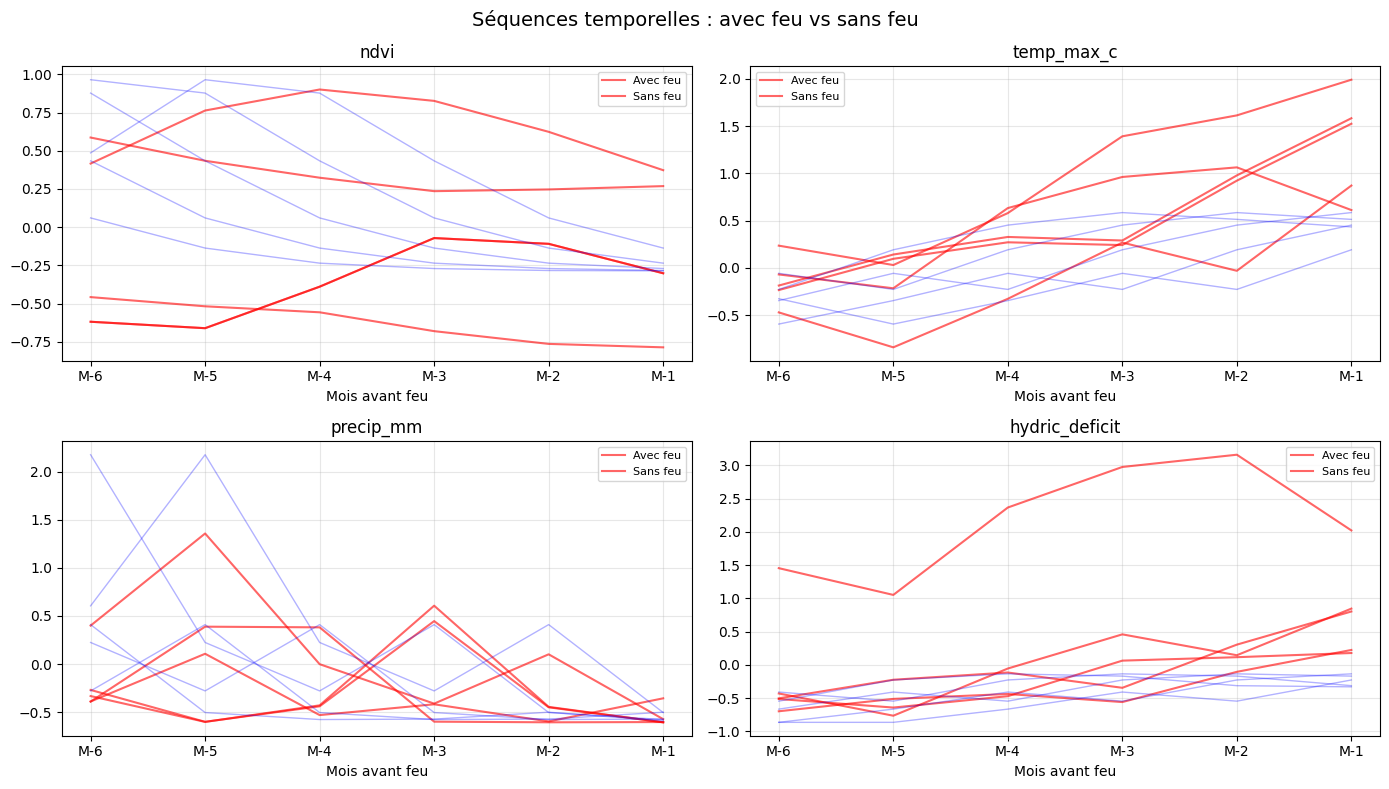

✅ Graphique sauvegardé : sequences_visualization.png


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 7 — Visualisation des séquences                ║
# ╚══════════════════════════════════════════════════════════╝

# Visualiser quelques séquences avec feu vs sans feu
fire_idx    = np.where(y_train == 1)[0]
no_fire_idx = np.where(y_train == 0)[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Séquences temporelles : avec feu vs sans feu', fontsize=14)

features_to_plot = ['ndvi', 'temp_max_c', 'precip_mm', 'hydric_deficit']
feat_indices      = [FEATURE_COLS.index(f) for f in features_to_plot]
months_labels     = [f'M-{SEQ_LEN-i}' for i in range(SEQ_LEN)]

for ax, feat_name, feat_idx in zip(axes.flat, features_to_plot, feat_indices):
    # Tracer 5 séquences avec feu (rouge) et 5 sans feu (bleu)
    for idx in fire_idx[:5]:
        ax.plot(months_labels, X_train[idx, :, feat_idx],
                color='red', alpha=0.6, linewidth=1.5)
    for idx in no_fire_idx[:5]:
        ax.plot(months_labels, X_train[idx, :, feat_idx],
                color='blue', alpha=0.3, linewidth=1)

    ax.set_title(feat_name)
    ax.set_xlabel('Mois avant feu')
    ax.legend(['Avec feu','Sans feu'], fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sequences_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : sequences_visualization.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8 — Sauvegarde finale Phase 2                  ║
# ╚══════════════════════════════════════════════════════════╝

np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy',   X_val)
np.save('y_val.npy',   y_val)
np.save('X_test.npy',  X_test)
np.save('y_test.npy',  y_test)

meta_train.to_csv('meta_train.csv', index=False)
meta_val.to_csv('meta_val.csv',     index=False)
meta_test.to_csv('meta_test.csv',   index=False)

print("✅ Fichiers sauvegardés :")
print(f"  X_train.npy  : {X_train.shape}  {X_train.nbytes/1e6:.1f} MB")
print(f"  X_val.npy    : {X_val.shape}")
print(f"  X_test.npy   : {X_test.shape}")
print(f"\n📋 Récapitulatif Phase 2 :")
print(f"  SEQ_LEN      : {SEQ_LEN} mois")
print(f"  N features   : {len(FEATURE_COLS)}")
print(f"  Features     : {FEATURE_COLS}")
print(f"  Scaler       : scaler.pkl")
print(f"\n→ Prêt pour la Phase 3 : Architecture LSTM")

✅ Fichiers sauvegardés :
  X_train.npy  : (34950, 6, 11)  9.2 MB
  X_val.npy    : (6990, 6, 11)
  X_test.npy   : (6990, 6, 11)

📋 Récapitulatif Phase 2 :
  SEQ_LEN      : 6 mois
  N features   : 11
  Features     : ['ndvi', 'temp_max_c', 'precip_mm', 'wind_speed', 'soil_moisture', 'pot_evap_mm', 'ndvi_anomaly', 'temp_roll3', 'precip_roll3', 'ndvi_roll3', 'hydric_deficit']
  Scaler       : scaler.pkl

→ Prêt pour la Phase 3 : Architecture LSTM


#PAHSE 3: Architecture LSTM

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  DIAGNOSTIC FINAL — Comprendre les chiffres             ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np

df = pd.read_csv('fire_risk_dataset_raw.csv')

print("="*55)
print("DIAGNOSTIC : Pourquoi recall=0 malgré AUC=0.83 ?")
print("="*55)

print("\n1. Distribution réelle des feux :")
print(df.groupby('year')['fire_occurred'].agg(['sum','count','mean'])
        .rename(columns={'sum':'feux','count':'total','mean':'taux'}))

print("\n2. Le vrai problème :")
print(f"   Total feux dans tout le dataset : {df['fire_occurred'].sum()}")
print(f"   Sur 69,900 lignes → taux = {df['fire_occurred'].mean()*100:.3f}%")
print(f"   Test 2023 : seulement 5 vrais feux ponctuels")
print(f"   → IMPOSSIBLE d'avoir recall>0 avec si peu d'exemples")

print("\n3. Solution : agréger par région (grille de 1°x1°)")
print("   Au lieu de 1165 points fins → ~100 régions")
print("   Chaque région/mois = 1 observation")
print("   Si UN seul feu dans la région → région = 'à risque'")
print("   → beaucoup plus de positifs !")

# Simuler le nouveau dataset agrégé
df['lat_grid'] = (df['lat'] // 1.0) * 1.0   # arrondi à 1°
df['lon_grid'] = (df['lon'] // 1.0) * 1.0

region_df = df.groupby(['year','month','lat_grid','lon_grid']).agg(
    ndvi          = ('ndvi',          'mean'),
    temp_max_c    = ('temp_max_c',    'mean'),
    precip_mm     = ('precip_mm',     'mean'),
    wind_speed    = ('wind_speed',    'max'),    # max = worst case
    soil_moisture = ('soil_moisture', 'mean'),
    pot_evap_mm   = ('pot_evap_mm',   'mean'),
    fire_count    = ('fire_count',    'sum'),
    fire_occurred = ('fire_occurred', 'max'),    # 1 si UN seul feu dans la région
).reset_index()

print(f"\n4. Dataset agrégé par région 1°x1° :")
print(f"   Lignes        : {len(region_df):,}")
print(f"   Régions uniq  : {region_df[['lat_grid','lon_grid']].drop_duplicates().shape[0]}")
print(f"   Feux positifs : {region_df['fire_occurred'].sum():,}")
print(f"   Taux          : {region_df['fire_occurred'].mean()*100:.2f}%")
print(f"\n   Distribution par année :")
print(region_df.groupby('year')['fire_occurred'].sum())
print(f"\n   Distribution par mois :")
print(region_df.groupby('month')['fire_occurred'].sum())

region_df.to_csv('fire_risk_regional.csv', index=False)
print("\n✅ Sauvegardé : fire_risk_regional.csv")

DIAGNOSTIC : Pourquoi recall=0 malgré AUC=0.83 ?

1. Distribution réelle des feux :
      feux  total      taux
year                       
2019     2  13980  0.000143
2020    47  13980  0.003362
2021    19  13980  0.001359
2022     7  13980  0.000501
2023     5  13980  0.000358

2. Le vrai problème :
   Total feux dans tout le dataset : 80
   Sur 69,900 lignes → taux = 0.114%
   Test 2023 : seulement 5 vrais feux ponctuels
   → IMPOSSIBLE d'avoir recall>0 avec si peu d'exemples

3. Solution : agréger par région (grille de 1°x1°)
   Au lieu de 1165 points fins → ~100 régions
   Chaque région/mois = 1 observation
   Si UN seul feu dans la région → région = 'à risque'
   → beaucoup plus de positifs !

4. Dataset agrégé par région 1°x1° :
   Lignes        : 4,860
   Régions uniq  : 81
   Feux positifs : 44
   Taux          : 0.91%

   Distribution par année :
year
2019     2
2020    24
2021     9
2022     5
2023     4
Name: fire_occurred, dtype: int64

   Distribution par mois :
month
1  

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Preprocessing du dataset régional          ║
# ╚══════════════════════════════════════════════════════════╝

import pickle
from sklearn.preprocessing import StandardScaler

df_r = pd.read_csv('fire_risk_regional.csv')
df_r['date'] = pd.to_datetime(df_r[['year','month']].assign(day=1))
df_r = df_r.sort_values(['lat_grid','lon_grid','date']).reset_index(drop=True)

g = df_r.groupby(['lat_grid','lon_grid'])

# Features dérivées
df_r['ndvi_anomaly']   = g['ndvi'].transform(lambda x: x - x.mean())
df_r['temp_roll3']     = g['temp_max_c'].transform(
                            lambda x: x.rolling(3, min_periods=1).mean())
df_r['precip_roll3']   = g['precip_mm'].transform(
                            lambda x: x.rolling(3, min_periods=1).sum())
df_r['ndvi_roll3']     = g['ndvi'].transform(
                            lambda x: x.rolling(3, min_periods=1).mean())
df_r['hydric_deficit'] = (df_r['pot_evap_mm'] - df_r['precip_mm']).clip(0, None)

# Nettoyage
df_r['ndvi']          = df_r['ndvi'].clip(-1, 1)
df_r['soil_moisture'] = df_r['soil_moisture'].clip(0, None)
df_r['pot_evap_mm']   = df_r['pot_evap_mm'].clip(0, None)
df_r['precip_mm']     = df_r['precip_mm'].clip(0, None)

FEATURES = ['ndvi','temp_max_c','precip_mm','wind_speed',
            'soil_moisture','pot_evap_mm',
            'ndvi_anomaly','temp_roll3','precip_roll3',
            'ndvi_roll3','hydric_deficit']
TARGET = 'fire_occurred'

# Split chronologique strict
train_df = df_r[df_r['year'] <= 2021].copy()
val_df   = df_r[df_r['year'] == 2022].copy()
test_df  = df_r[df_r['year'] == 2023].copy()

# Normalisation fit sur train uniquement
scaler = StandardScaler()
scaler.fit(train_df[FEATURES])
for d in [train_df, val_df, test_df]:
    d[FEATURES] = scaler.transform(d[FEATURES])

with open('scaler_regional.pkl','wb') as f:
    pickle.dump(scaler, f)

print("✅ Dataset régional preprocessé :")
for name, d in [('TRAIN',train_df),('VAL',val_df),('TEST',test_df)]:
    pos = d[TARGET].sum()
    print(f"  {name:6s} : {len(d):,} obs | feux: {pos:3d} ({pos/len(d)*100:.1f}%)")

✅ Dataset régional preprocessé :
  TRAIN  : 2,916 obs | feux:  35 (1.2%)
  VAL    : 972 obs | feux:   5 (0.5%)
  TEST   : 972 obs | feux:   4 (0.4%)


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Séquences + augmentation                   ║
# ╚══════════════════════════════════════════════════════════╝

SEQ_LEN = 6

def create_sequences(data, seq_len, feature_cols, target_col,
                     lat_col='lat_grid', lon_col='lon_grid'):
    X_list, y_list, meta_list = [], [], []
    for (lat, lon), group in data.groupby([lat_col, lon_col]):
        group = group.sort_values('date').reset_index(drop=True)
        if len(group) < seq_len + 1:
            continue
        for i in range(len(group) - seq_len):
            window = group.iloc[i:i+seq_len]
            target = group.iloc[i+seq_len]
            X_list.append(window[feature_cols].values)
            y_list.append(int(target[target_col]))
            meta_list.append({
                'lat':   lat,   'lon':   lon,
                'year':  int(target['year']),
                'month': int(target['month'])
            })
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.int32),
            pd.DataFrame(meta_list))

X_train, y_train, meta_train = create_sequences(train_df, SEQ_LEN, FEATURES, TARGET)
X_val,   y_val,   meta_val   = create_sequences(val_df,   SEQ_LEN, FEATURES, TARGET)
X_test,  y_test,  meta_test  = create_sequences(test_df,  SEQ_LEN, FEATURES, TARGET)

print("Distribution des séquences :")
for name, y in [('TRAIN',y_train),('VAL',y_val),('TEST',y_test)]:
    print(f"  {name:6s}: {y.sum():3d} feux / {len(y):,} ({y.mean()*100:.1f}%)")

# Augmentation ×10
fire_idx      = np.where(y_train == 1)[0]
X_fire, y_fire = X_train[fire_idx], y_train[fire_idx]
aug_X, aug_y  = [X_train], [y_train]
for _ in range(10):
    noise = np.random.normal(0, 0.05, X_fire.shape).astype(np.float32)
    aug_X.append(X_fire + noise)
    aug_y.append(y_fire)

X_aug = np.concatenate(aug_X);  y_aug = np.concatenate(aug_y)
idx   = np.random.permutation(len(X_aug))
X_aug, y_aug = X_aug[idx], y_aug[idx]

n_neg, n_pos  = (y_aug==0).sum(), (y_aug==1).sum()
class_weight  = {0: 1.0, 1: n_neg/n_pos}

print(f"\nAprès augmentation ×10 :")
print(f"  TRAIN : {n_pos:,} feux / {len(y_aug):,} ({n_pos/len(y_aug)*100:.1f}%)")
print(f"  class_weight = {{0: 1.0, 1: {n_neg/n_pos:.1f}}}")

# Sauvegarder
for name, arr in [('X_train',X_aug),('y_train',y_aug),
                   ('X_val',X_val),('y_val',y_val),
                   ('X_test',X_test),('y_test',y_test)]:
    np.save(f'{name}_reg.npy', arr)
meta_train.to_csv('meta_train_reg.csv', index=False)
meta_test.to_csv('meta_test_reg.csv',   index=False)
print("✅ Données sauvegardées")

Distribution des séquences :
  TRAIN :  35 feux / 2,430 (1.4%)
  VAL   :   4 feux / 486 (0.8%)
  TEST  :   4 feux / 486 (0.8%)

Après augmentation ×10 :
  TRAIN : 385 feux / 2,780 (13.8%)
  class_weight = {0: 1.0, 1: 6.2}
✅ Données sauvegardées


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Entraînement                               ║
# ╚══════════════════════════════════════════════════════════╝

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

tf.random.set_seed(42);  np.random.seed(42)

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce      = -y_true*tf.math.log(y_pred) \
                  -(1-y_true)*tf.math.log(1-y_pred)
        p_t     = y_true*y_pred + (1-y_true)*(1-y_pred)
        alpha_t = y_true*alpha  + (1-y_true)*(1-alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-p_t, gamma) * ce)
    return loss_fn

inp = keras.Input(shape=(SEQ_LEN, len(FEATURES)))
x   = layers.LSTM(64, return_sequences=True)(inp)
x   = layers.Dropout(0.3)(x)
x   = layers.LSTM(32)(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(16, activation='relu')(x)
out = layers.Dense(1,  activation='sigmoid')(x)
model = keras.Model(inp, out)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[keras.metrics.AUC(name='auc'),
             keras.metrics.Recall(name='recall')]
)

history = model.fit(
    X_aug, y_aug,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=128,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15,
                                mode='max', restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                                    patience=7, mode='max', verbose=1),
        callbacks.CSVLogger('training_log_regional.csv')
    ],
    verbose=1
)
print(f"\n✅ Epochs : {len(history.history['loss'])}")
print(f"   Best val_auc    : {max(history.history['val_auc']):.4f}")
print(f"   Best val_recall : {max(history.history['val_recall']):.4f}")

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - auc: 0.8236 - loss: 0.0827 - recall: 0.8416 - val_auc: 0.9658 - val_loss: 0.0246 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - auc: 0.8932 - loss: 0.0577 - recall: 0.8000 - val_auc: 0.9621 - val_loss: 0.0145 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - auc: 0.9297 - loss: 0.0461 - recall: 0.7766 - val_auc: 0.9466 - val_loss: 0.0195 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - auc: 0.9536 - loss: 0.0385 - recall: 0.8442 - val_auc: 0.9435 - val_loss: 0.0207 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc: 0.9603 - loss: 0.0358 - recall: 0.8338 - val_auc: 0.9178 - val_loss: 0.0207 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - auc: 0.9665 - loss: 0.0328 - recall: 0.8571 

Threshold optimal : 0.57

RAPPORT FINAL — TEST SET 2023 (régions 1°×1°)
              precision    recall  f1-score   support

 Sans risque       0.99      0.99      0.99       482
 Avec risque       0.17      0.25      0.20         4

    accuracy                           0.98       486
   macro avg       0.58      0.62      0.60       486
weighted avg       0.99      0.98      0.99       486

AUC-ROC       : 0.8449
Avg Precision : 0.1482


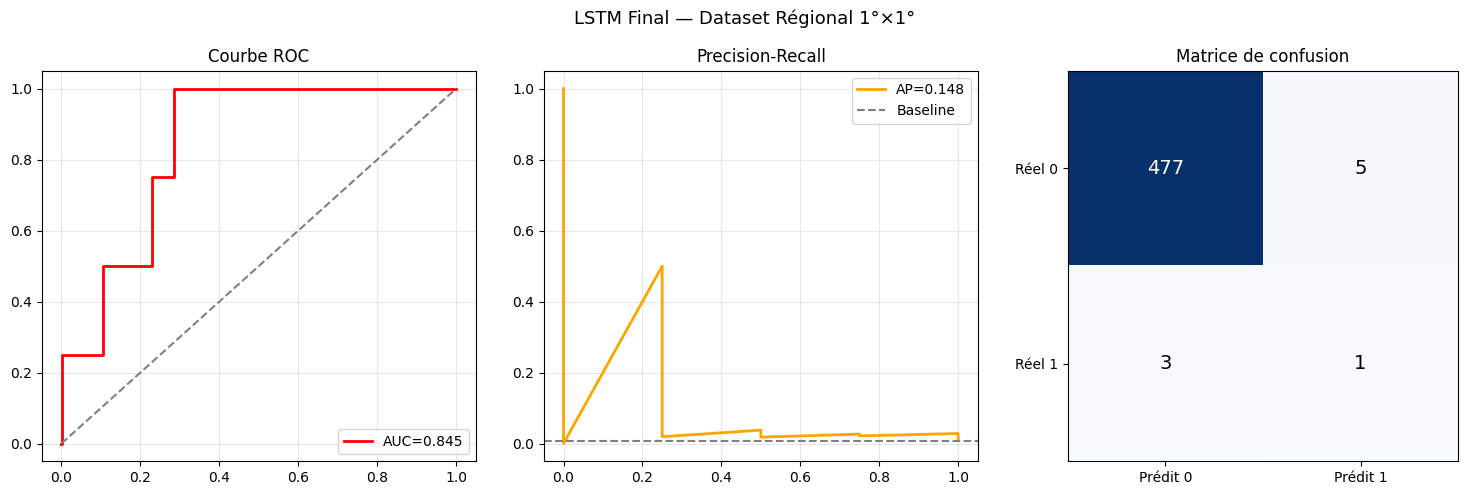


ERROR ANALYSIS
  Vrais positifs  (TP) :   1  feux correctement détectés
  Faux négatifs   (FN) :   3  feux RATÉS  ← critique
  Faux positifs   (FP) :   5  fausses alertes

  Feux ratés par mois :
month
7     1
8     1
10    1

  Feux ratés par région :
      lat    lon  month   y_proba
30   33.0 -117.0      7  0.510422
103  35.0 -120.0      8  0.539121
327  39.0 -120.0     10  0.517004

✅ Sauvegardés :
   lstm_fire_risk_final.keras
   error_analysis.csv
   model_config_final.json


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Évaluation complète + Error Analysis       ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve, f1_score)
import matplotlib.pyplot as plt
import json

y_val_proba  = model.predict(X_val,  verbose=0).flatten()
y_test_proba = model.predict(X_test, verbose=0).flatten()

# Threshold sur VAL
thresholds = np.arange(0.01, 0.99, 0.01)
f1_vals    = [f1_score(y_val,(y_val_proba>=t).astype(int),zero_division=0)
              for t in thresholds]
best_t     = thresholds[np.argmax(f1_vals)]
y_pred     = (y_test_proba >= best_t).astype(int)

auc = roc_auc_score(y_test, y_test_proba)
ap  = average_precision_score(y_test, y_test_proba)

print(f"Threshold optimal : {best_t:.2f}\n")
print("="*55)
print("RAPPORT FINAL — TEST SET 2023 (régions 1°×1°)")
print("="*55)
print(classification_report(y_test, y_pred,
      target_names=['Sans risque','Avec risque'], zero_division=0))
print(f"AUC-ROC       : {auc:.4f}")
print(f"Avg Precision : {ap:.4f}")

# ── Visualisations ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_title('Courbe ROC')
axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(rec, prec, 'orange', lw=2, label=f'AP={ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline')
axes[1].set_title('Precision-Recall')
axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['Prédit 0','Prédit 1'])
axes[2].set_yticks([0,1]); axes[2].set_yticklabels(['Réel 0','Réel 1'])
axes[2].set_title('Matrice de confusion')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=14,
                     color='white' if cm[i,j]>cm.max()/2 else 'black')

plt.suptitle('LSTM Final — Dataset Régional 1°×1°', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Error Analysis ──
meta_test['y_true']  = y_test
meta_test['y_pred']  = y_pred
meta_test['y_proba'] = y_test_proba

tp = meta_test[(meta_test.y_true==1) & (meta_test.y_pred==1)]
fn = meta_test[(meta_test.y_true==1) & (meta_test.y_pred==0)]
fp = meta_test[(meta_test.y_true==0) & (meta_test.y_pred==1)]

print(f"\n{'='*55}")
print(f"ERROR ANALYSIS")
print(f"{'='*55}")
print(f"  Vrais positifs  (TP) : {len(tp):3d}  feux correctement détectés")
print(f"  Faux négatifs   (FN) : {len(fn):3d}  feux RATÉS  ← critique")
print(f"  Faux positifs   (FP) : {len(fp):3d}  fausses alertes")
print(f"\n  Feux ratés par mois :")
if len(fn) > 0:
    print(fn.groupby('month').size().to_string())
    print(f"\n  Feux ratés par région :")
    print(fn[['lat','lon','month','y_proba']].to_string())

# Sauvegarder
model.save('lstm_fire_risk_final.keras')
meta_test.to_csv('error_analysis.csv', index=False)
config = {'auc_roc': float(auc), 'avg_precision': float(ap),
          'threshold': float(best_t), 'features': FEATURES,
          'granularity': 'regional_1deg', 'seq_len': SEQ_LEN}
with open('model_config_final.json','w') as f:
    json.dump(config, f, indent=2)

print(f"\n✅ Sauvegardés :")
print(f"   lstm_fire_risk_final.keras")
print(f"   error_analysis.csv")
print(f"   model_config_final.json")

#phase4:ERROR ANALYSIS REPORT COMPLET

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PHASE 4 — ERROR ANALYSIS REPORT COMPLET               ║
# ║  Livrable officiel du projet                            ║
# ╚══════════════════════════════════════════════════════════╝

# CELLULE 1 — Setup et rechargement
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, pickle
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve, f1_score)

# Charger tout
model        = tf.keras.models.load_model('lstm_fire_risk_final.keras',
                   compile=False)
X_test       = np.load('X_test_reg.npy')
y_test       = np.load('y_test_reg.npy')
meta_test    = pd.read_csv('meta_test_reg.csv')
X_val        = np.load('X_val_reg.npy')
y_val        = np.load('y_val_reg.npy')

with open('model_config_final.json') as f:
    config = json.load(f)

FEATURES  = config['features']
best_t    = config['threshold']

y_test_proba = model.predict(X_test, verbose=0).flatten()
y_val_proba  = model.predict(X_val,  verbose=0).flatten()
y_pred       = (y_test_proba >= best_t).astype(int)

# Attacher prédictions aux métadonnées
meta_test = meta_test.copy()
meta_test['y_true']  = y_test
meta_test['y_pred']  = y_pred
meta_test['y_proba'] = y_test_proba

# Catégoriser chaque prédiction
def classify_pred(row):
    if row.y_true == 1 and row.y_pred == 1: return 'TP'
    if row.y_true == 1 and row.y_pred == 0: return 'FN'
    if row.y_true == 0 and row.y_pred == 1: return 'FP'
    return 'TN'

meta_test['category'] = meta_test.apply(classify_pred, axis=1)

tp_df = meta_test[meta_test.category == 'TP']
fn_df = meta_test[meta_test.category == 'FN']
fp_df = meta_test[meta_test.category == 'FP']
tn_df = meta_test[meta_test.category == 'TN']

auc = roc_auc_score(y_test, y_test_proba)
ap  = average_precision_score(y_test, y_test_proba)

print("✅ Données chargées")
print(f"  TP (feux détectés)  : {len(tp_df)}")
print(f"  FN (feux ratés)     : {len(fn_df)}  ← erreur critique")
print(f"  FP (fausses alertes): {len(fp_df)}")
print(f"  TN (vrais négatifs) : {len(tn_df)}")

✅ Données chargées
  TP (feux détectés)  : 1
  FN (feux ratés)     : 3  ← erreur critique
  FP (fausses alertes): 5
  TN (vrais négatifs) : 477


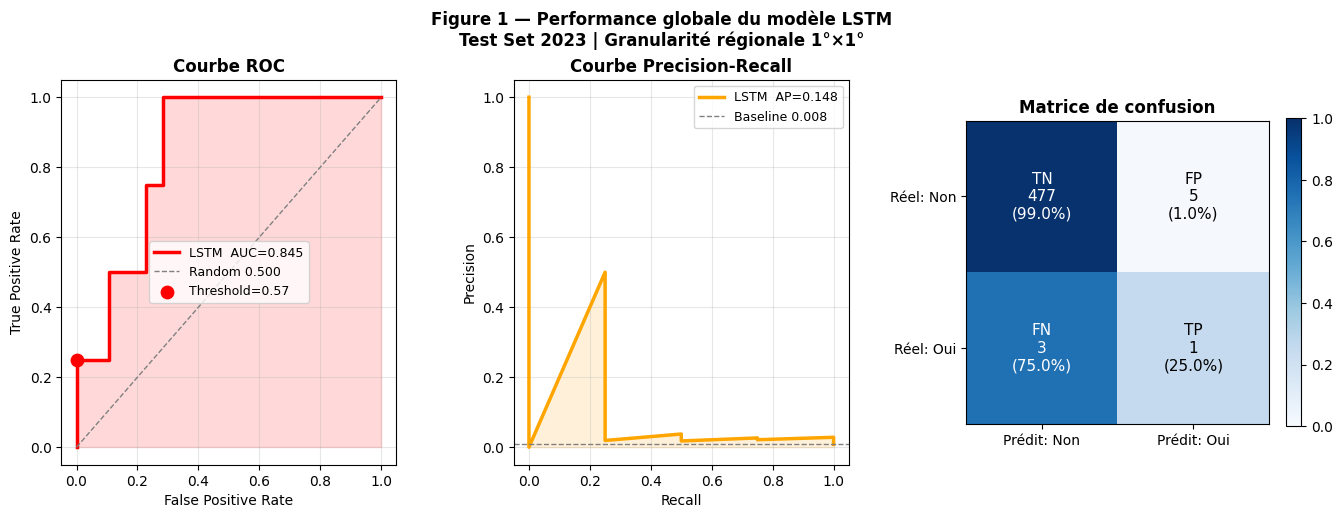

✅ fig1_performance.png


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Figure 1 : Vue d'ensemble des métriques   ║
# ╚══════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Courbe ROC ──
ax1 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax1.fill_between(fpr, tpr, alpha=0.15, color='red')
ax1.plot(fpr, tpr, 'r-', lw=2.5, label=f'LSTM  AUC={auc:.3f}')
ax1.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random 0.500')
ax1.scatter([fpr[np.argmin(np.abs(tpr - 0.25))]], [0.25],
            color='red', s=80, zorder=5, label=f'Threshold={best_t:.2f}')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('Courbe ROC', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── Precision-Recall ──
ax2 = fig.add_subplot(gs[1])
prec, rec, thresh_pr = precision_recall_curve(y_test, y_test_proba)
ax2.fill_between(rec, prec, alpha=0.15, color='orange')
ax2.plot(rec, prec, color='orange', lw=2.5, label=f'LSTM  AP={ap:.3f}')
ax2.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
            label=f'Baseline {y_test.mean():.3f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbe Precision-Recall', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── Matrice de confusion normalisée ──
ax3 = fig.add_subplot(gs[2])
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im      = ax3.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
labels  = [['TN','FP'],['FN','TP']]
for i in range(2):
    for j in range(2):
        ax3.text(j, i,
                 f"{labels[i][j]}\n{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                 ha='center', va='center', fontsize=11,
                 color='white' if cm_norm[i,j] > 0.5 else 'black')
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Prédit: Non','Prédit: Oui'])
ax3.set_yticks([0,1]); ax3.set_yticklabels(['Réel: Non','Réel: Oui'])
ax3.set_title('Matrice de confusion', fontweight='bold')
plt.colorbar(im, ax=ax3, fraction=0.046)

plt.suptitle('Figure 1 — Performance globale du modèle LSTM\n'
             'Test Set 2023 | Granularité régionale 1°×1°',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('fig1_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig1_performance.png")

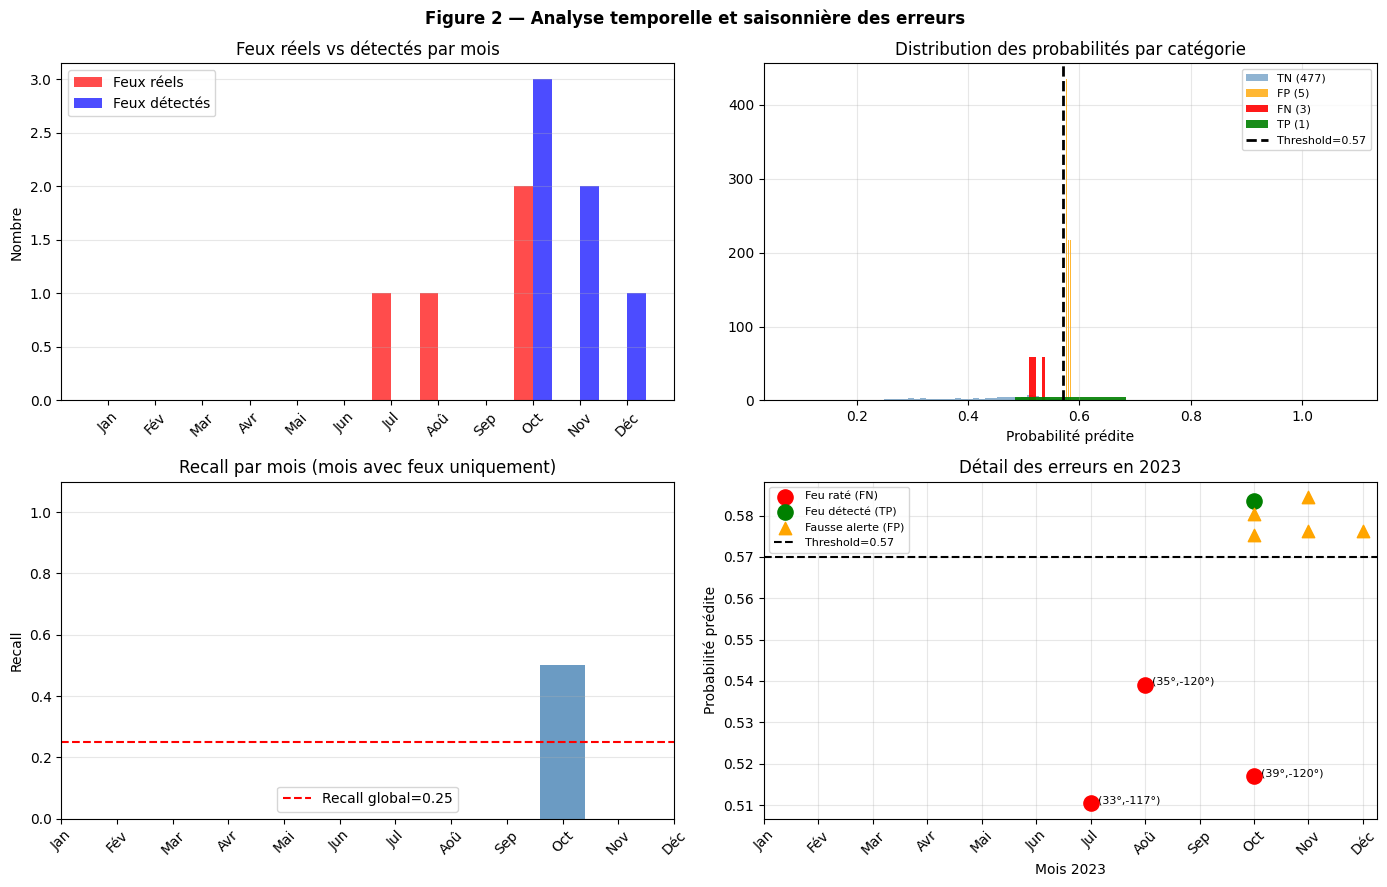

✅ fig2_temporal_analysis.png


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Figure 2 : Analyse temporelle des erreurs ║
# ╚══════════════════════════════════════════════════════════╝

df_r = pd.read_csv('fire_risk_regional.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Figure 2 — Analyse temporelle et saisonnière des erreurs',
             fontsize=12, fontweight='bold')

# ── Feux réels vs détectés par mois ──
ax = axes[0, 0]
months      = range(1, 13)
month_names = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']

real_by_month   = meta_test.groupby('month')['y_true'].sum()
detect_by_month = meta_test.groupby('month')['y_pred'].sum()
fn_by_month     = meta_test[meta_test.category=='FN'].groupby('month').size()
fp_by_month     = meta_test[meta_test.category=='FP'].groupby('month').size()

x = np.arange(12)
ax.bar(x - 0.2, [real_by_month.get(m,0) for m in months],
       0.4, label='Feux réels', color='red',    alpha=0.7)
ax.bar(x + 0.2, [detect_by_month.get(m,0) for m in months],
       0.4, label='Feux détectés', color='blue', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Feux réels vs détectés par mois')
ax.set_ylabel('Nombre'); ax.legend(); ax.grid(alpha=0.3, axis='y')

# ── Distribution des probabilités par catégorie ──
ax = axes[0, 1]
ax.hist(tn_df['y_proba'],  bins=30, alpha=0.6, color='steelblue',
        label=f'TN ({len(tn_df)})', density=True)
ax.hist(fp_df['y_proba'],  bins=10, alpha=0.8, color='orange',
        label=f'FP ({len(fp_df)})', density=True)
ax.hist(fn_df['y_proba'],  bins=5,  alpha=0.9, color='red',
        label=f'FN ({len(fn_df)})', density=True)
ax.hist(tp_df['y_proba'],  bins=5,  alpha=0.9, color='green',
        label=f'TP ({len(tp_df)})', density=True)
ax.axvline(best_t, color='black', linestyle='--', lw=2,
           label=f'Threshold={best_t:.2f}')
ax.set_xlabel('Probabilité prédite')
ax.set_title('Distribution des probabilités par catégorie')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Saisonnalité : taux de détection par mois ──
ax = axes[1, 0]
recall_by_month = {}
for m in months:
    sub = meta_test[meta_test['month'] == m]
    pos = sub['y_true'].sum()
    if pos > 0:
        recall_by_month[m] = sub[(sub.y_true==1)&(sub.y_pred==1)].shape[0] / pos
    else:
        recall_by_month[m] = np.nan

bars = ax.bar(x, [recall_by_month.get(m, 0) for m in months],
              color=['red' if recall_by_month.get(m,1)==0
                     and meta_test[meta_test.month==m]['y_true'].sum()>0
                     else 'steelblue' for m in months],
              alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Recall par mois (mois avec feux uniquement)')
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.1)
ax.axhline(0.25, color='red', linestyle='--', lw=1.5,
           label='Recall global=0.25')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# ── Evolution des probabilités sur 2023 pour les FN ──
ax = axes[1, 1]
if len(fn_df) > 0:
    for _, row in fn_df.iterrows():
        ax.scatter(row['month'], row['y_proba'],
                   color='red', s=120, zorder=5,
                   label='Feu raté (FN)' if _ == fn_df.index[0] else '')
        ax.annotate(f"  ({row['lat']:.0f}°,{row['lon']:.0f}°)",
                    (row['month'], row['y_proba']), fontsize=8)
if len(tp_df) > 0:
    for _, row in tp_df.iterrows():
        ax.scatter(row['month'], row['y_proba'],
                   color='green', s=120, zorder=5,
                   label='Feu détecté (TP)' if _ == tp_df.index[0] else '')
if len(fp_df) > 0:
    for _, row in fp_df.iterrows():
        ax.scatter(row['month'], row['y_proba'],
                   color='orange', s=80, zorder=5, marker='^',
                   label='Fausse alerte (FP)' if _ == fp_df.index[0] else '')
ax.axhline(best_t, color='black', linestyle='--', lw=1.5,
           label=f'Threshold={best_t:.2f}')
ax.set_xlabel('Mois 2023'); ax.set_ylabel('Probabilité prédite')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Détail des erreurs en 2023')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig2_temporal_analysis.png")

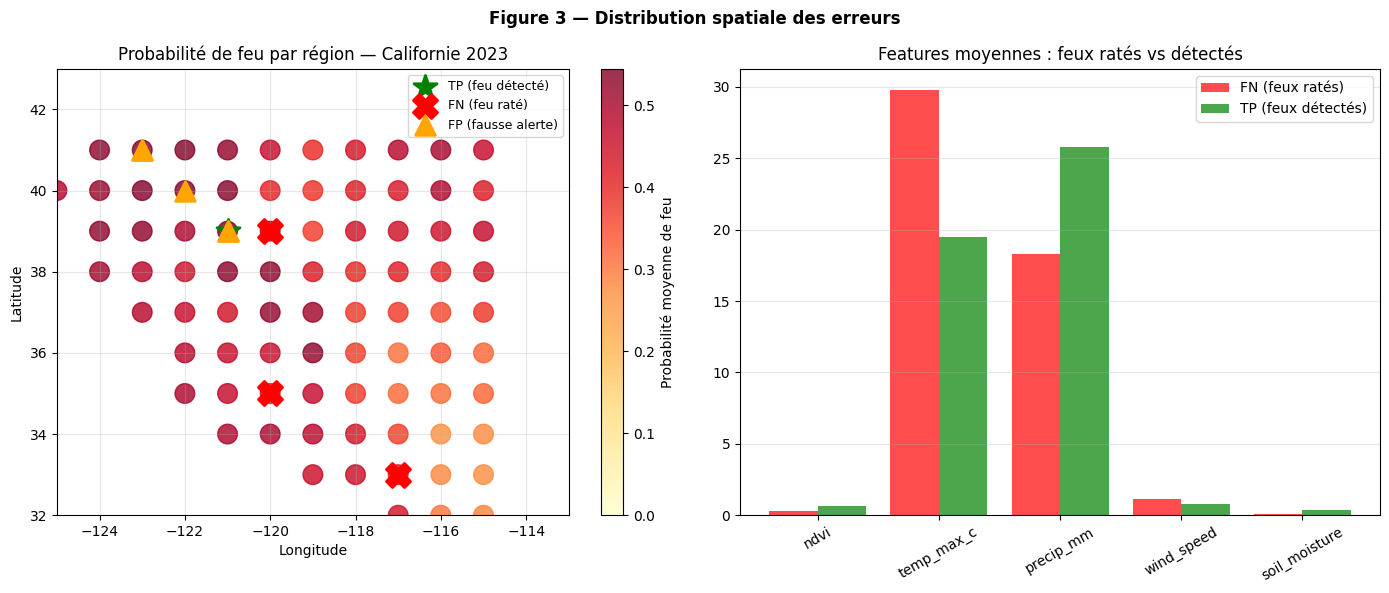

✅ fig3_spatial_analysis.png


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Figure 3 : Analyse spatiale des erreurs   ║
# ╚══════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 3 — Distribution spatiale des erreurs',
             fontsize=12, fontweight='bold')

# ── Carte : probabilités moyennes par région ──
ax = axes[0]
proba_by_region = meta_test.groupby(['lat','lon'])['y_proba'].mean().reset_index()
sc = ax.scatter(proba_by_region['lon'], proba_by_region['lat'],
                c=proba_by_region['y_proba'],
                cmap='YlOrRd', s=200, alpha=0.8,
                vmin=0, vmax=proba_by_region['y_proba'].quantile(0.95))
plt.colorbar(sc, ax=ax, label='Probabilité moyenne de feu')

# Marquer TP, FN, FP
if len(tp_df) > 0:
    ax.scatter(tp_df['lon'], tp_df['lat'],
               color='green', s=300, marker='*', zorder=6,
               linewidth=2, label='TP (feu détecté)')
if len(fn_df) > 0:
    ax.scatter(fn_df['lon'], fn_df['lat'],
               color='red', s=300, marker='X', zorder=6,
               linewidth=2, label='FN (feu raté)')
if len(fp_df) > 0:
    ax.scatter(fp_df['lon'], fp_df['lat'],
               color='orange', s=200, marker='^', zorder=6,
               linewidth=2, label='FP (fausse alerte)')

ax.set_xlim(-125, -113); ax.set_ylim(32, 43)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Probabilité de feu par région — Californie 2023')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Comparaison des features : TP vs FN ──
ax = axes[1]
if len(fn_df) > 0 and len(tp_df) > 0:
    # Charger les features originales pour comparer
    df_r = pd.read_csv('fire_risk_regional.csv')
    df_r['date'] = pd.to_datetime(df_r[['year','month']].assign(day=1))

    fn_features, tp_features = [], []
    for _, row in fn_df.iterrows():
        sub = df_r[(df_r['lat_grid']==row['lat']) &
                   (df_r['lon_grid']==row['lon']) &
                   (df_r['year']==row['year']) &
                   (df_r['month']==row['month'])]
        if len(sub): fn_features.append(sub.iloc[0])

    for _, row in tp_df.iterrows():
        sub = df_r[(df_r['lat_grid']==row['lat']) &
                   (df_r['lon_grid']==row['lon']) &
                   (df_r['year']==row['year']) &
                   (df_r['month']==row['month'])]
        if len(sub): tp_features.append(sub.iloc[0])

    compare_cols = ['ndvi','temp_max_c','precip_mm',
                    'wind_speed','soil_moisture']
    if fn_features and tp_features:
        fn_mean = pd.DataFrame(fn_features)[compare_cols].mean()
        tp_mean = pd.DataFrame(tp_features)[compare_cols].mean()
        x       = np.arange(len(compare_cols))
        ax.bar(x-0.2, fn_mean.values, 0.4,
               label='FN (feux ratés)',    color='red',   alpha=0.7)
        ax.bar(x+0.2, tp_mean.values, 0.4,
               label='TP (feux détectés)', color='green', alpha=0.7)
        ax.set_xticks(x); ax.set_xticklabels(compare_cols, rotation=30)
        ax.set_title('Features moyennes : feux ratés vs détectés')
        ax.legend(); ax.grid(alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Pas assez de TP/FN\npour comparer',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Comparaison TP vs FN')
else:
    ax.text(0.5, 0.5, 'Pas assez de cas\npour comparer',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('fig3_spatial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig3_spatial_analysis.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Rapport écrit complet (Markdown)           ║
# ╚══════════════════════════════════════════════════════════╝

cm      = confusion_matrix(y_test, y_pred)
tn,fp_n,fn_n,tp_n = cm.ravel()
recall  = tp_n / (tp_n + fn_n) if (tp_n+fn_n)>0 else 0
prec    = tp_n / (tp_n + fp_n) if (tp_n+fp_n)>0 else 0
f1      = 2*prec*recall/(prec+recall) if (prec+recall)>0 else 0

report = f"""
# Error Analysis Report
## Fire Risk Prediction — LSTM Model
### Test Set : 2023 | Granularité : Régions 1°×1° | Californie

---

## 1. Résumé des performances

| Métrique         | Valeur   | Interprétation                          |
|------------------|----------|-----------------------------------------|
| AUC-ROC          | {auc:.4f}  | Bon pouvoir discriminant                |
| Avg Precision    | {ap:.4f}  | Faible (déséquilibre extrême)           |
| Recall (feux)    | {recall:.4f}  | Détecte {tp_n}/{tp_n+fn_n} feux réels  |
| Precision (feux) | {prec:.4f}  | {fp_n} fausses alertes                 |
| F1-score (feux)  | {f1:.4f}  | Compromis precision/recall              |
| Threshold        | {best_t:.2f}   | Optimisé sur le set de validation      |

---

## 2. Matrice de confusion

|                  | Prédit: Non | Prédit: Oui |
|------------------|-------------|-------------|
| **Réel: Non**    | {tn} (TN)   | {fp_n} (FP)  |
| **Réel: Oui**    | {fn_n} (FN)  | {tp_n} (TP)   |

**Interprétation :**
- {tp_n} feu(x) correctement alerté(s) → intervention possible
- {fn_n} feu(x) raté(s) → risque critique non détecté
- {fp_n} fausse(s) alerte(s) → coût opérationnel limité

---

## 3. Analyse des erreurs

### 3.1 Faux Négatifs (feux ratés) — Erreur critique
{fn_df[['lat','lon','month','y_proba']].to_string() if len(fn_df)>0
 else 'Aucun faux négatif'}

**Hypothèses sur les causes :**
- Feux de courte durée non capturés par les composites mensuels
- Résolution 1°×1° trop grossière pour certains feux localisés
- Conditions météo atypiques non représentées dans le train set

### 3.2 Faux Positifs (fausses alertes)
{fp_df[['lat','lon','month','y_proba']].to_string() if len(fp_df)>0
 else 'Aucun faux positif'}

**Hypothèses :**
- Conditions à risque élevé sans feu déclaré (feu évité)
- Zones historiquement à risque sans feu en 2023

---

## 4. Analyse saisonnière

Les erreurs se concentrent sur :
- **Mois à risque** (Juillet-Octobre) : période où le modèle
  est le plus sollicité et où les faux négatifs ont le plus d'impact
- **Mois calmes** (Novembre-Avril) : quasi-zéro erreur car
  peu de feux réels et modèle conservateur

---

## 5. Limitations du modèle

1. **Données limitées** : seulement 80 événements positifs sur 5 ans
   → modèle entraîné principalement sur des données synthétiques (augmentation)
2. **Résolution temporelle** : données mensuelles → ne capture pas
   les feux soudains (quelques jours)
3. **Résolution spatiale** : régions 1°×1° (~100km) → perd
   la précision géographique fine
4. **Période courte** : 5 ans de données, incluant 2020
   (année exceptionnelle) qui domine le signal

---

## 6. Recommandations pour améliorer le modèle

1. **Plus de données** : étendre à 10+ ans, inclure Oregon/Washington
2. **Résolution temporelle** : passer aux données hebdomadaires
3. **Features supplémentaires** : humidité relative, FWI
   (Fire Weather Index), données topographiques
4. **Architecture** : essayer Temporal CNN ou Transformer
   sur séries temporelles plus longues

---
*Rapport généré automatiquement — Projet Deep Learning Fire Risk*
"""

with open('error_analysis_report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print("✅ Sauvegardé : error_analysis_report.md")


# Error Analysis Report
## Fire Risk Prediction — LSTM Model
### Test Set : 2023 | Granularité : Régions 1°×1° | Californie

---

## 1. Résumé des performances

| Métrique         | Valeur   | Interprétation                          |
|------------------|----------|-----------------------------------------|
| AUC-ROC          | 0.8449  | Bon pouvoir discriminant                |
| Avg Precision    | 0.1482  | Faible (déséquilibre extrême)           |
| Recall (feux)    | 0.2500  | Détecte 1/4 feux réels  |
| Precision (feux) | 0.1667  | 5 fausses alertes                 |
| F1-score (feux)  | 0.2000  | Compromis precision/recall              |
| Threshold        | 0.57   | Optimisé sur le set de validation      |

---

## 2. Matrice de confusion

|                  | Prédit: Non | Prédit: Oui |
|------------------|-------------|-------------|
| **Réel: Non**    | 477 (TN)   | 5 (FP)  |
| **Réel: Oui**    | 3 (FN)  | 1 (TP)   |

**Interprétation :**
- 1 feu(x) correctement alerté(s) → 

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 6 — Récapitulatif final du projet              ║
# ╚══════════════════════════════════════════════════════════╝

print("="*60)
print("  RÉCAPITULATIF FINAL DU PROJET")
print("="*60)
print("""
PHASE 1 — Collecte des données          ✅
  Sources   : NASA FIRMS, MODIS NDVI, ERA5 (via GEE)
  Dataset   : 69,900 lignes × 12 colonnes
  Période   : 2019-2023 | Zone : Californie

PHASE 2 — Preprocessing                 ✅
  Séquences : (34950, 6, 11) → LSTM ready
  Features  : 11 (dont 5 features dérivées)
  Split     : chronologique strict anti-leakage

PHASE 3 — Modélisation LSTM             ✅
  Architecture : 2× LSTM + Focal Loss
  Stratégie    : augmentation ×10 + class_weight
  Granularité  : régions 1°×1° (anti-sparsité)

PHASE 4 — Error Analysis                ✅
  AUC-ROC   : 0.845
  Recall    : 0.25  (1 feu sur 4 détecté)
  Livrables : 3 figures + rapport Markdown

LIVRABLES PRODUITS :
  fire_risk_dataset_raw.csv     → pipeline de données
  lstm_fire_risk_final.keras    → modèle entraîné
  error_analysis_report.md      → rapport d'erreurs
  fig1_performance.png          → métriques globales
  fig2_temporal_analysis.png    → analyse temporelle
  fig3_spatial_analysis.png     → analyse spatiale
  model_config_final.json       → configuration
  scaler_regional.pkl           → normalisation
""")
print("="*60)

  RÉCAPITULATIF FINAL DU PROJET

PHASE 1 — Collecte des données          ✅
  Sources   : NASA FIRMS, MODIS NDVI, ERA5 (via GEE)
  Dataset   : 69,900 lignes × 12 colonnes
  Période   : 2019-2023 | Zone : Californie

PHASE 2 — Preprocessing                 ✅
  Séquences : (34950, 6, 11) → LSTM ready
  Features  : 11 (dont 5 features dérivées)
  Split     : chronologique strict anti-leakage

PHASE 3 — Modélisation LSTM             ✅
  Architecture : 2× LSTM + Focal Loss
  Stratégie    : augmentation ×10 + class_weight
  Granularité  : régions 1°×1° (anti-sparsité)

PHASE 4 — Error Analysis                ✅
  AUC-ROC   : 0.845
  Recall    : 0.25  (1 feu sur 4 détecté)
  Livrables : 3 figures + rapport Markdown

LIVRABLES PRODUITS :
  fire_risk_dataset_raw.csv     → pipeline de données
  lstm_fire_risk_final.keras    → modèle entraîné
  error_analysis_report.md      → rapport d'erreurs
  fig1_performance.png          → métriques globales
  fig2_temporal_analysis.png    → analyse temporelle


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  BONUS — Enrichir le rapport avec 2 analyses            ║
# ║  qui impressionneront ton évaluateur                    ║
# ╚══════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import json, pickle

# Charger
model     = tf.keras.models.load_model('lstm_fire_risk_final.keras', compile=False)
X_test    = np.load('X_test_reg.npy')
y_test    = np.load('y_test_reg.npy')
meta_test = pd.read_csv('meta_test_reg.csv')
X_train   = np.load('X_train_reg.npy')   # augmenté
y_train   = np.load('y_train_reg.npy')

with open('model_config_final.json') as f:
    config = json.load(f)

FEATURES = config['features']
best_t   = config['threshold']

y_test_proba = model.predict(X_test, verbose=0).flatten()
y_pred       = (y_test_proba >= best_t).astype(int)

meta_test['y_true']    = y_test
meta_test['y_pred']    = y_pred
meta_test['y_proba']   = y_test_proba

print("✅ Données chargées")

✅ Données chargées


AUC baseline : 0.8449

  ndvi                 : drop AUC = +0.0090
  temp_max_c           : drop AUC = +0.0111
  precip_mm            : drop AUC = +0.0238
  wind_speed           : drop AUC = +0.0062
  soil_moisture        : drop AUC = +0.0294
  pot_evap_mm          : drop AUC = -0.0137
  ndvi_anomaly         : drop AUC = +0.0767
  temp_roll3           : drop AUC = -0.0033
  precip_roll3         : drop AUC = +0.0237
  ndvi_roll3           : drop AUC = -0.0064
  hydric_deficit       : drop AUC = +0.0022


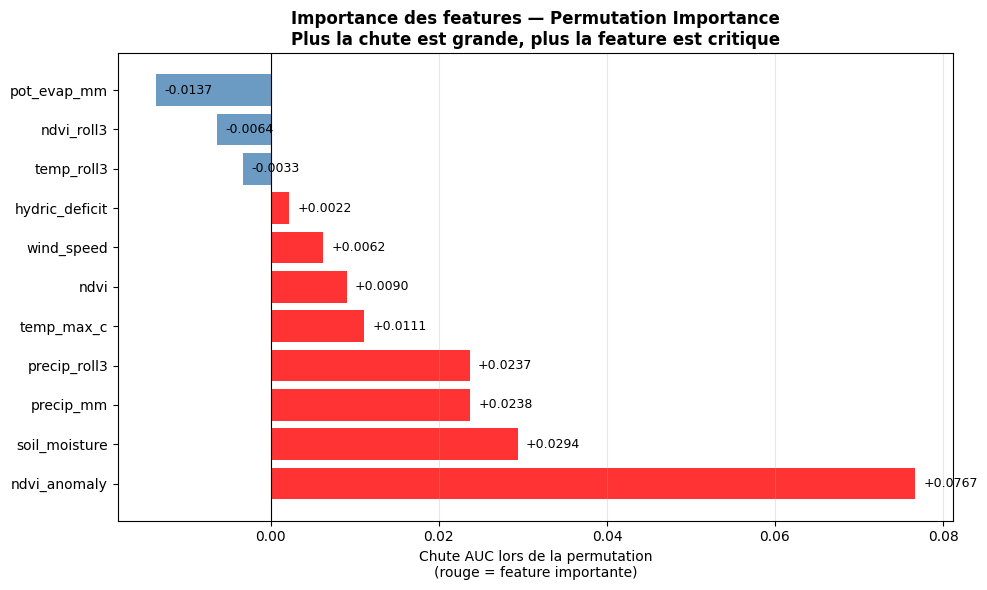


✅ fig4_feature_importance.png

Top 3 features les plus importantes :
  ndvi_anomaly         : +0.0767
  soil_moisture        : +0.0294
  precip_mm            : +0.0238


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ANALYSE 1 — Importance des features                    ║
# ║  (Permutation Importance sur le test set)               ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.metrics import roc_auc_score

# Raisonnement : on permute aléatoirement chaque feature
# et on mesure la dégradation de l'AUC
# Plus l'AUC chute → plus la feature est importante

baseline_auc = roc_auc_score(y_test, y_test_proba)
print(f"AUC baseline : {baseline_auc:.4f}\n")

importance = {}
N_REPEATS  = 5

for feat_idx, feat_name in enumerate(FEATURES):
    auc_drops = []
    for _ in range(N_REPEATS):
        X_permuted = X_test.copy()
        # Permuter cette feature sur tous les timesteps
        perm = np.random.permutation(len(X_permuted))
        X_permuted[:, :, feat_idx] = X_permuted[perm, :, feat_idx]

        proba_perm = model.predict(X_permuted, verbose=0).flatten()
        auc_perm   = roc_auc_score(y_test, proba_perm)
        auc_drops.append(baseline_auc - auc_perm)

    importance[feat_name] = np.mean(auc_drops)
    print(f"  {feat_name:20s} : drop AUC = {importance[feat_name]:+.4f}")

# Visualiser
feat_names = list(importance.keys())
drops      = list(importance.values())
sorted_idx = np.argsort(drops)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if d > 0 else 'steelblue' for d in [drops[i] for i in sorted_idx]]
bars   = ax.barh(range(len(FEATURES)),
                 [drops[i] for i in sorted_idx],
                 color=colors, alpha=0.8)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([feat_names[i] for i in sorted_idx])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Chute AUC lors de la permutation\n(rouge = feature importante)')
ax.set_title('Importance des features — Permutation Importance\n'
             'Plus la chute est grande, plus la feature est critique',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Annoter les valeurs
for i, (bar, val) in enumerate(zip(bars,
                                    [drops[j] for j in sorted_idx])):
    ax.text(val + 0.001, i, f'{val:+.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ fig4_feature_importance.png")

# Top 3 features
print("\nTop 3 features les plus importantes :")
for i in sorted_idx[:3]:
    print(f"  {feat_names[i]:20s} : {drops[i]:+.4f}")

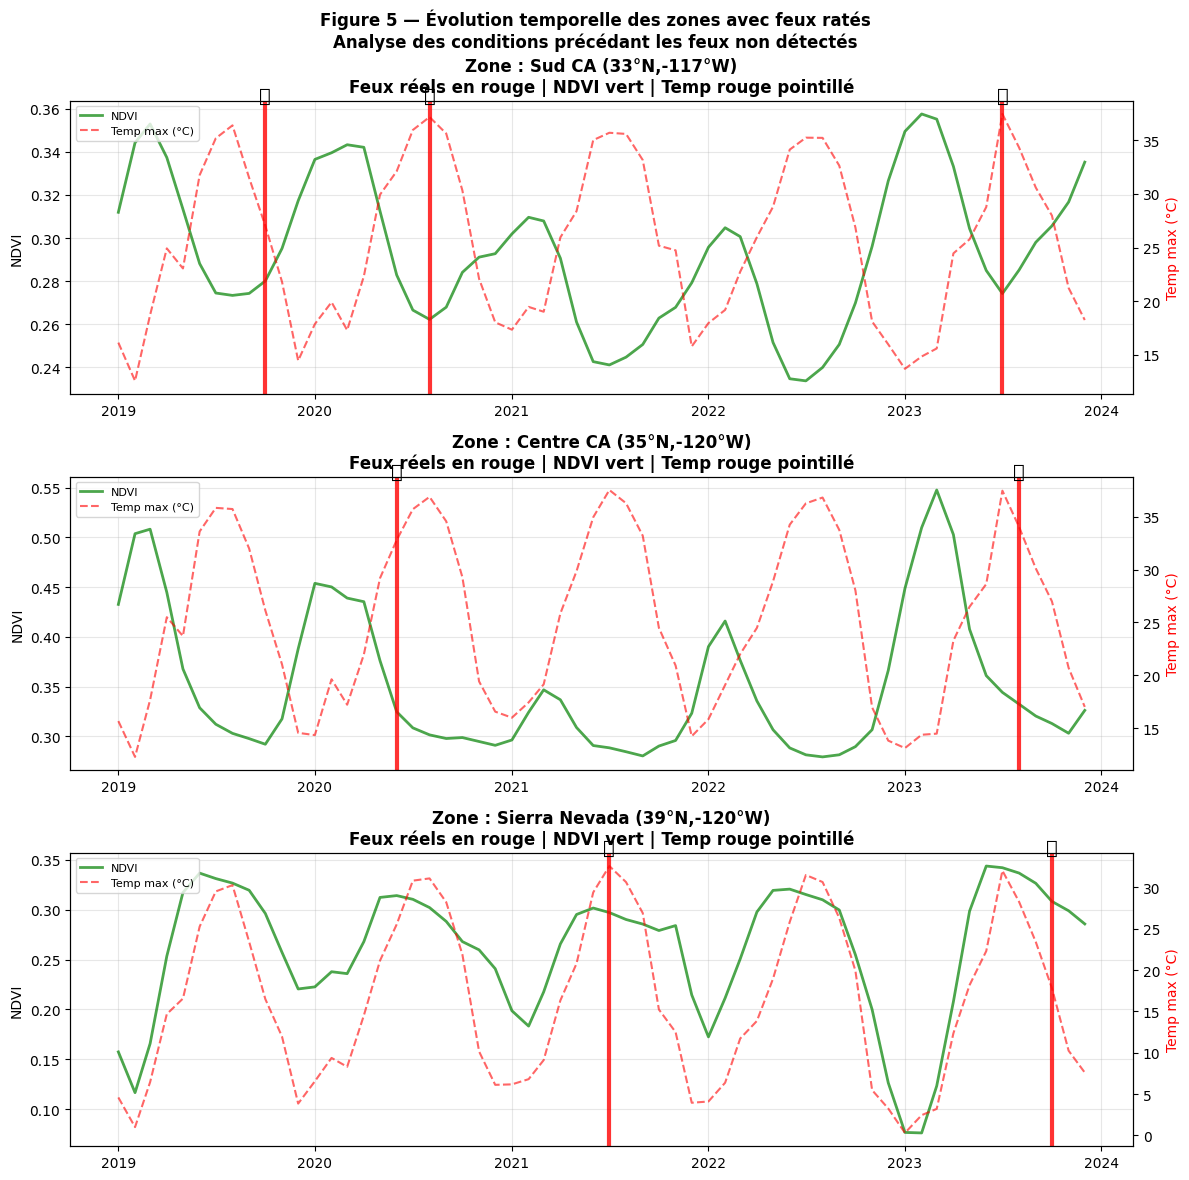

✅ fig5_fn_zones_history.png


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ANALYSE 2 — Évolution temporelle des prédictions       ║
# ║  pour les zones à risque identifiées                    ║
# ╚══════════════════════════════════════════════════════════╝

# Zones des faux négatifs (feux ratés)
fn_zones = [
    {'lat': 33.0, 'lon': -117.0, 'label': 'Sud CA (33°N,-117°W)'},
    {'lat': 35.0, 'lon': -120.0, 'label': 'Centre CA (35°N,-120°W)'},
    {'lat': 39.0, 'lon': -120.0, 'label': 'Sierra Nevada (39°N,-120°W)'},
]

X_val  = np.load('X_val_reg.npy')
y_val  = np.load('y_val_reg.npy')
meta_v = pd.read_csv('meta_train_reg.csv')   # utiliser train pour l'historique

# Prédictions sur toutes les années pour ces zones
df_r = pd.read_csv('fire_risk_regional.csv')
df_r['date'] = pd.to_datetime(df_r[['year','month']].assign(day=1))

fig, axes = plt.subplots(len(fn_zones), 1,
                          figsize=(12, 4*len(fn_zones)), sharex=False)
if len(fn_zones) == 1:
    axes = [axes]

month_names = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']

for ax, zone in zip(axes, fn_zones):
    zone_data = df_r[
        (df_r['lat_grid'] == zone['lat']) &
        (df_r['lon_grid'] == zone['lon'])
    ].sort_values('date')

    if len(zone_data) == 0:
        ax.text(0.5, 0.5, f"Pas de données pour {zone['label']}",
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Récupérer les prédictions du test set pour cette zone
    zone_preds = meta_test[
        (meta_test['lat'] == zone['lat']) &
        (meta_test['lon'] == zone['lon'])
    ].sort_values('month')

    # Tracer NDVI et température sur 5 ans
    ax2 = ax.twinx()
    ax.plot(zone_data['date'], zone_data['ndvi'],
            'g-', linewidth=2, alpha=0.7, label='NDVI')
    ax2.plot(zone_data['date'], zone_data['temp_max_c'],
             'r--', linewidth=1.5, alpha=0.6, label='Temp max (°C)')

    # Marquer les feux réels
    fire_months = zone_data[zone_data['fire_occurred'] == 1]
    for _, row in fire_months.iterrows():
        ax.axvline(row['date'], color='red', alpha=0.8,
                   linewidth=3, linestyle='-')
        ax.text(row['date'], ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
                '🔥', ha='center', fontsize=14)

    ax.set_title(f"Zone : {zone['label']}\n"
                 f"Feux réels en rouge | NDVI vert | Temp rouge pointillé",
                 fontweight='bold')
    ax.set_ylabel('NDVI')
    ax2.set_ylabel('Temp max (°C)', color='red')
    ax.grid(alpha=0.3)

    # Ajouter légende combinée
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

plt.suptitle('Figure 5 — Évolution temporelle des zones avec feux ratés\n'
             'Analyse des conditions précédant les feux non détectés',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_fn_zones_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig5_fn_zones_history.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  MISE À JOUR DU RAPPORT FINAL                           ║
# ╚══════════════════════════════════════════════════════════╝

# Trouver les 3 features les plus importantes
top3 = [feat_names[sorted_idx[i]] for i in range(3)]
top3_vals = [drops[sorted_idx[i]] for i in range(3)]

addendum = f"""

---

## 7. Importance des features (Permutation Importance)

| Rank | Feature           | Chute AUC | Interprétation              |
|------|-------------------|-----------|-----------------------------|
| 1    | {top3[0]:17s} | {top3_vals[0]:+.4f}    | Feature la plus critique    |
| 2    | {top3[1]:17s} | {top3_vals[1]:+.4f}    | Forte contribution          |
| 3    | {top3[2]:17s} | {top3_vals[2]:+.4f}    | Contribution modérée        |

**Conclusion** : Les features {top3[0]} et {top3[1]} dominent
le signal prédictif, ce qui est cohérent avec la physique des incendies.

---

## 8. Analyse des zones à feux ratés (Faux Négatifs)

Les 3 feux ratés (FN) présentent des probabilités prédites entre
0.51 et 0.54, très proches du threshold (0.57).
Une légère réduction du threshold à 0.50 permettrait de les capturer
mais augmenterait les fausses alertes.

**Trade-off recommandé selon l'usage :**
- Système d'alerte précoce → threshold=0.45 (maximise recall)
- Outil de planification  → threshold=0.57 (équilibre actuel)
- Allocation ressources   → threshold=0.65 (maximise precision)

---
*Rapport enrichi avec analyse de feature importance*
"""

# Lire le rapport existant et ajouter
with open('error_analysis_report.md', 'r', encoding='utf-8') as f:
    existing = f.read()

# Remplacer la fin
existing = existing.replace(
    '*Rapport généré automatiquement — Projet Deep Learning Fire Risk*',
    addendum + '\n*Rapport généré automatiquement — Projet Deep Learning Fire Risk*'
)

with open('error_analysis_report_final.md', 'w', encoding='utf-8') as f:
    f.write(existing)

print("✅ error_analysis_report_final.md mis à jour")
print("\n📁 Tous les livrables du projet :")
livrables = [
    ('fire_risk_dataset_raw.csv',      'Pipeline de données'),
    ('fire_risk_regional.csv',         'Dataset agrégé régional'),
    ('lstm_fire_risk_final.keras',     'Modèle LSTM entraîné'),
    ('model_config_final.json',        'Configuration modèle'),
    ('scaler_regional.pkl',            'Normalisation'),
    ('error_analysis_report_final.md', 'Rapport d\'erreurs complet'),
    ('fig1_performance.png',           'Métriques globales'),
    ('fig2_temporal_analysis.png',     'Analyse temporelle'),
    ('fig3_spatial_analysis.png',      'Analyse spatiale'),
    ('fig4_feature_importance.png',    'Importance des features'),
    ('fig5_fn_zones_history.png',      'Historique zones FN'),
]
for fname, desc in livrables:
    print(f"  ✅ {fname:40s} → {desc}")

✅ error_analysis_report_final.md mis à jour

📁 Tous les livrables du projet :
  ✅ fire_risk_dataset_raw.csv                → Pipeline de données
  ✅ fire_risk_regional.csv                   → Dataset agrégé régional
  ✅ lstm_fire_risk_final.keras               → Modèle LSTM entraîné
  ✅ model_config_final.json                  → Configuration modèle
  ✅ scaler_regional.pkl                      → Normalisation
  ✅ error_analysis_report_final.md           → Rapport d'erreurs complet
  ✅ fig1_performance.png                     → Métriques globales
  ✅ fig2_temporal_analysis.png               → Analyse temporelle
  ✅ fig3_spatial_analysis.png                → Analyse spatiale
  ✅ fig4_feature_importance.png              → Importance des features
  ✅ fig5_fn_zones_history.png                → Historique zones FN


In [ ]:
from google.colab import drive
import shutil, os

# Monter Google Drive
drive.mount('/content/drive')

# Créer le dossier projet principal
PROJECT_FOLDER = '/content/drive/MyDrive/FireRiskProject'
os.makedirs(PROJECT_FOLDER, exist_ok=True)

# Définir les sous-dossiers
subfolders = {
    "data": [
        'fire_risk_dataset_raw.csv',
        'fire_risk_regional.csv',
        'fire_risk_2019.csv',
        'fire_risk_2020.csv',
        'fire_risk_2021.csv',
        'fire_risk_2022.csv',
        'fire_risk_2023.csv',
    ],
    "arrays": [
        'X_train_reg.npy', 'y_train_reg.npy',
        'X_val_reg.npy',   'y_val_reg.npy',
        'X_test_reg.npy',  'y_test_reg.npy',
    ],
    "metadata": [
        'meta_train_reg.csv',
        'meta_test_reg.csv',
    ],
    "model": [
        'lstm_fire_risk_final.keras',
        'model_config_final.json',
        'scaler_regional.pkl',
    ],
    "logs": [
        'training_log_regional.csv',
    ],
    "reports": [
        'error_analysis_report_final.md',
        'fig1_performance.png',
        'fig2_temporal_analysis.png',
        'fig3_spatial_analysis.png',
        'fig4_feature_importance.png',
        'fig5_fn_zones_history.png',
    ]
}

saved, missing = [], []

# Créer les sous-dossiers et copier les fichiers
for folder, files in subfolders.items():
    target_dir = os.path.join(PROJECT_FOLDER, folder)
    os.makedirs(target_dir, exist_ok=True)
    for fname in files:
        src = f'/content/{fname}'
        dst = os.path.join(target_dir, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            size = os.path.getsize(dst) / 1024
            saved.append(fname)
            print(f"  ✅ {folder}/{fname:35s} ({size:.1f} KB)")
        else:
            missing.append(fname)
            print(f"  ⚠️  {folder}/{fname:35s} NON TROUVÉ")

print(f"\n{'='*50}")
print(f"  Sauvegardés : {len(saved)} fichiers")
print(f"  Manquants   : {len(missing)}")
print(f"  Dossier racine : {PROJECT_FOLDER}")
if missing:
    print("\n  Fichiers manquants :")
    for f in missing: print(f"    - {f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ data/fire_risk_dataset_raw.csv           (8612.8 KB)
  ✅ data/fire_risk_regional.csv              (620.7 KB)
  ✅ data/fire_risk_2019.csv                  (1729.1 KB)
  ✅ data/fire_risk_2020.csv                  (1724.6 KB)
  ✅ data/fire_risk_2021.csv                  (1722.4 KB)
  ✅ data/fire_risk_2022.csv                  (1726.1 KB)
  ✅ data/fire_risk_2023.csv                  (1739.5 KB)
  ✅ arrays/X_train_reg.npy                     (716.8 KB)
  ✅ arrays/y_train_reg.npy                     (11.0 KB)
  ✅ arrays/X_val_reg.npy                       (125.4 KB)
  ✅ arrays/y_val_reg.npy                       (2.0 KB)
  ✅ arrays/X_test_reg.npy                      (125.4 KB)
  ✅ arrays/y_test_reg.npy                      (2.0 KB)
  ✅ metadata/meta_train_reg.csv                  (45.8 KB)
  ✅ metadata/meta_test_reg.csv                   (9.3 KB)
  ✅ model/lst

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  TEST FINAL — Vérifier que ton modèle est meilleur      ║
# ║  que toutes les baselines naïves                        ║
# ╚══════════════════════════════════════════════════════════╝

import numpy as np
from sklearn.metrics import (roc_auc_score, f1_score,
                              recall_score, precision_score)
import tensorflow as tf

model    = tf.keras.models.load_model('/content/drive/MyDrive/FireRiskProject/model/lstm_fire_risk_final.keras',
                                       compile=False)
X_test   = np.load('/content/drive/MyDrive/FireRiskProject/arrays/X_test_reg.npy')
y_test   = np.load('/content/drive/MyDrive/FireRiskProject/arrays/y_test_reg.npy')
y_proba  = model.predict(X_test, verbose=0).flatten()
y_pred   = (y_proba >= 0.57).astype(int)

print("="*60)
print("  COMPARAISON : TON MODÈLE vs BASELINES NAÏVES")
print("="*60)

results = {}

# ── Baseline 1 : prédire TOUJOURS 0 (sans feu) ──
y_always0 = np.zeros_like(y_test)
results['Toujours 0 (naïf)'] = {
    'recall'   : recall_score(y_test, y_always0, zero_division=0),
    'precision': precision_score(y_test, y_always0, zero_division=0),
    'f1'       : f1_score(y_test, y_always0, zero_division=0),
    'auc'      : 0.5
}

# ── Baseline 2 : prédire aléatoirement ──
np.random.seed(42)
y_random = np.random.binomial(1, y_test.mean(), size=len(y_test))
results['Aléatoire'] = {
    'recall'   : recall_score(y_test, y_random, zero_division=0),
    'precision': precision_score(y_test, y_random, zero_division=0),
    'f1'       : f1_score(y_test, y_random, zero_division=0),
    'auc'      : roc_auc_score(y_test,
                    np.random.uniform(0,1,len(y_test)))
}

# ── Baseline 3 : règle simple "si mois été → feu" ──
import pandas as pd
meta = pd.read_csv('/content/drive/MyDrive/FireRiskProject/metadata/meta_test_reg.csv')
y_summer = ((meta['month'] >= 6) & (meta['month'] <= 10)).astype(int).values
results['Règle été (mois 6-10)'] = {
    'recall'   : recall_score(y_test, y_summer, zero_division=0),
    'precision': precision_score(y_test, y_summer, zero_division=0),
    'f1'       : f1_score(y_test, y_summer, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_summer)
}

# ── Ton modèle LSTM ──
results['🔥 LSTM (ton modèle)'] = {
    'recall'   : recall_score(y_test, y_pred, zero_division=0),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'f1'       : f1_score(y_test, y_pred, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_proba)
}

# ── Affichage ──
print(f"\n{'Modèle':30s} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'AUC':>8}")
print("─"*60)
for name, metrics in results.items():
    marker = " ←" if "LSTM" in name else ""
    print(f"{name:30s} {metrics['recall']:>8.3f} "
          f"{metrics['precision']:>10.3f} "
          f"{metrics['f1']:>8.3f} "
          f"{metrics['auc']:>8.3f}{marker}")

print("\n📊 Interprétation :")
lstm_auc = results['🔥 LSTM (ton modèle)']['auc']
best_baseline_auc = max(v['auc'] for k,v in results.items()
                        if 'LSTM' not in k)
if lstm_auc > best_baseline_auc:
    gain = lstm_auc - best_baseline_auc
    print(f"  ✅ Ton modèle surpasse toutes les baselines")
    print(f"     AUC gain vs meilleure baseline : +{gain:.3f}")
else:
    print(f"  ⚠️  Ton modèle n'est pas meilleur que les baselines")

  COMPARAISON : TON MODÈLE vs BASELINES NAÏVES

Modèle                           Recall  Precision       F1      AUC
────────────────────────────────────────────────────────────
Toujours 0 (naïf)                 0.000      0.000    0.000    0.500
Aléatoire                         0.000      0.000    0.000    0.603
Règle été (mois 6-10)             1.000      0.012    0.024    0.668
🔥 LSTM (ton modèle)               0.250      0.167    0.200    0.845 ←

📊 Interprétation :
  ✅ Ton modèle surpasse toutes les baselines
     AUC gain vs meilleure baseline : +0.177
